# MIMIC_Extract Analysis

Scenario-based pipeline evaluation with Aurora visual style.

In [1]:
import warnings
import pickle
from pathlib import Path
from typing import List, Tuple

from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401  needed for 3-D projection
from scipy.interpolate import griddata
from scipy.stats import binom
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tabulate import tabulate
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': '#191a1c',
    'axes.facecolor':   '#191a1c',
    'text.color':       'white',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
})


# Setup

In [2]:
CURATED_ROOT        = Path('..') / 'data' / 'curated'
ANALYSIS_CACHE_DIR  = Path('..') / 'data' / 'scenario_analysis'

SCENARIOS = [
    'age35_range5',  'age35_range10',  'age35_range15',
    'age45_range5',  'age45_range10',  'age45_range15',
    'age55_range5',  'age55_range10',  'age55_range15',
    'min48hr', 'min18age', 'minperc5',
]

AGG_METHODS = [
    'mean', 'median', 'standard deviation', 'mean deviation', 'maximum deviation'
]

LABELS     = ['icu_los', 'mortality']
SEEDS      = [22, 985, 439, 81]
TEST_SIZE  = 0.2
MAX_RECORDS_PER_SCENARIO = None
MODEL_KWARGS = dict(max_iter=500, solver='liblinear', random_state=0)
FALLBACK_BASELINE_SCENARIO = 'baseline_nofilters'
EXCLUDED_EXPERIMENTS       = {'baseline_nofilters_fast'}

VITAL_NAMES = [
    'Heart Rate',
    'Systolic blood pressure',
    'Diastolic blood pressure',
    'Mean blood pressure',
    'Respiratory rate',
    'Temperature',
    'Oxygen saturation',
]

LABEL_DISPLAY = {
    'icu_los':   'icu_los (ICU stay > 3 days)',
    'mortality': 'mort_hosp / hospital_expire_flag  (hospital mortality)',
}

ANALYSIS_CACHE_DIR.mkdir(parents=True, exist_ok=True)
print('Curated root:', CURATED_ROOT.resolve())
print('Variants    :', len(SCENARIOS))


Curated root: /home/ccampb47/work/MIMIC_Extract/data/curated
Variants    : 12


In [3]:
# ── index helpers ──────────────────────────────────────────────────────────────

def _get_time_level_name(x_index):
    names = list(x_index.names)
    for c in ['hours_in', 'time', 'hour', 'Hour']:
        if c in names:
            return c
    return names[-1]

def _record_id_levels(x_index):
    t = _get_time_level_name(x_index)
    return [n for n in x_index.names if n != t]

def _select_pos_label(patients_df, target_label):
    if target_label == 'icu_los':
        return (patients_df['los_icu'] > 3).astype(int)
    if target_label == 'mortality':
        for col in ('mort_hosp', 'hospital_expire_flag'):
            if col in patients_df.columns:
                return patients_df[col].astype(int)
        raise KeyError('No mortality column found in patients_df')
    raise ValueError(f'Unknown target label: {target_label}')

def _ensure_multiindex(arr, names):
    if isinstance(arr, pd.MultiIndex):
        return arr
    return pd.MultiIndex.from_tuples([tuple(t) for t in arr], names=names)

# ── I/O helpers ────────────────────────────────────────────────────────────────

def _pick_datafile(scenario_dir):
    for c in ('all_hourly_data.h5', 'all_hourly_data_5000.h5', 'all_hourly_data_2000.h5'):
        fp = scenario_dir / c
        if fp.exists():
            return fp
    raise FileNotFoundError(f'No all_hourly_data*.h5 found in {scenario_dir}')

def load_curated_scenario(scenario_name, data_root=CURATED_ROOT, load_X=True):
    scenario_dir = data_root / scenario_name
    datafile     = _pick_datafile(scenario_dir)
    X = pd.read_hdf(str(datafile), 'vitals_labs') if load_X else None
    patients = pd.read_hdf(str(datafile), 'patients')
    try:
        interventions = pd.read_hdf(str(datafile), 'interventions')
    except Exception:
        interventions = None
    return {'name': scenario_name, 'X': X, 'patients': patients,
            'interventions': interventions, 'datafile': datafile}

def maybe_sample_record_ids(patients_df, max_records):
    if max_records is None or len(patients_df) <= max_records:
        return patients_df
    return patients_df.sample(max_records, random_state=0)

def subset_X_by_patients(X, patients_df):
    time_level = _get_time_level_name(X.index)
    rec_index  = X.index.droplevel(time_level)
    return X[rec_index.isin(patients_df.index)]

# ── aggregation ────────────────────────────────────────────────────────────────

def build_record_aggregated_features(X, method):
    rec_levels = _record_id_levels(X.index)
    g = X.groupby(level=rec_levels)
    if method == 'mean':
        return g.mean()
    if method == 'median':
        return g.median()
    if method == 'standard deviation':
        return g.std(ddof=1)
    if method == 'mean deviation':
        def _mean_dev(df):
            return (df.sub(df.mean(axis=0), axis=1).abs()).mean(axis=0)
        return g.apply(_mean_dev)
    if method == 'maximum deviation':
        def _max_dev(df):
            return (df.sub(df.mean(axis=0), axis=1).abs()).max(axis=0)
        return g.apply(_max_dev)
    raise ValueError(f'Unknown method: {method}')

# ── lens-plot helpers ──────────────────────────────────────────────────────────

def _find_feature_name(feature_map, target_name):
    key = target_name.lower()
    if key in feature_map:
        return feature_map[key]
    aliases = {
        'Heart Rate':               ['heart rate', 'heartrate', 'pulse'],
        'Systolic blood pressure':  ['systolic blood pressure', 'sbp'],
        'Diastolic blood pressure': ['diastolic blood pressure', 'dbp'],
        'Mean blood pressure':      ['mean blood pressure', 'map'],
        'Respiratory rate':         ['respiratory rate', 'resp rate', 'rr'],
        'Temperature':              ['temperature', 'temp'],
        'Oxygen saturation':        ['oxygen saturation', 'spo2', 'o2 saturation'],
    }.get(target_name, [target_name.lower()])
    for alias in aliases:
        if alias in feature_map:
            return feature_map[alias]
    return None

def _aggregate_series_by_hour(series, hour_values, method):
    s = pd.Series(series.values, index=hour_values)
    if method == 'mean':
        return s.groupby(level=0).mean()
    if method == 'median':
        return s.groupby(level=0).median()
    if method == 'standard deviation':
        return s.groupby(level=0).std(ddof=1)
    if method == 'mean deviation':
        return s.groupby(level=0).apply(lambda x: (x - x.mean()).abs().mean())
    if method == 'maximum deviation':
        return s.groupby(level=0).apply(lambda x: (x - x.mean()).abs().max())
    raise ValueError(f'Unknown method: {method}')

def build_lens_method_hour_matrix(X, requested_feature, requested_methods):
    if not isinstance(X.columns, pd.MultiIndex):
        raise ValueError('Expected MultiIndex columns in vitals_labs.')
    time_level  = _get_time_level_name(X.index)
    hour_values = X.index.get_level_values(time_level)
    all_hours   = np.sort(np.asarray(pd.Index(hour_values).unique(), dtype=int))
    mean_cols   = [c for c in X.columns if str(c[1]).lower() == 'mean']
    feature_map = {str(c[0]).lower(): str(c[0]) for c in mean_cols}
    actual = _find_feature_name(feature_map, requested_feature)
    if actual is None:
        matrix = pd.DataFrame(np.nan, index=requested_methods, columns=all_hours)
        matrix.columns.name = 'Hour'
        matrix.index.name   = 'Aggregation'
        return matrix, True
    col  = next(c for c in mean_cols if str(c[0]) == actual)
    rows = []
    for method in requested_methods:
        agg = _aggregate_series_by_hour(X[col], hour_values, method).reindex(all_hours)
        rows.append(pd.Series(agg.values, index=all_hours, name=method))
    matrix = pd.DataFrame(rows, index=requested_methods)
    matrix.columns.name = 'Hour'
    matrix.index.name   = 'Aggregation'
    return matrix, False

# ── evaluation helpers ─────────────────────────────────────────────────────────

def impute_and_scale(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    col_means = X.mean(axis=0, skipna=True).fillna(0.0)
    X = X.fillna(col_means).fillna(0.0)
    scaler = StandardScaler()
    return scaler.fit_transform(X.values), scaler, col_means

def mcnemar_counts(y_true, pred_a, pred_b):
    y = np.asarray(y_true).astype(int)
    a_c = np.asarray(pred_a).astype(int) == y
    b_c = np.asarray(pred_b).astype(int) == y
    return int(np.sum(~a_c & b_c)), int(np.sum(a_c & ~b_c))

def mcnemar_pooled(n01, n10):
    n = n01 + n10
    if n == 0:
        return 0.0, 1.0
    stat   = (abs(n01 - n10) - 1.0) ** 2 / n
    p_one  = binom.cdf(min(n01, n10), n, 0.5)
    return float(stat), float(min(1.0, 2.0 * p_one))

def compute_centroid(X_agg, patients_df, target_label):
    y   = _select_pos_label(patients_df, target_label)
    y   = y.loc[X_agg.index]
    sel = y.values == 1
    if sel.sum() == 0:
        return None
    block     = X_agg.loc[y.index[sel]]
    col_means = block.mean(axis=0, skipna=True)
    vec       = block.fillna(col_means).mean(axis=0, skipna=True).values
    return np.nan_to_num(vec, nan=0.0, posinf=0.0, neginf=0.0)

def extract_vital_centroid(X_agg, patients_df, target_label, vital_names, polarity='pos'):
    y   = _select_pos_label(patients_df, target_label)
    y   = y.loc[X_agg.index]
    sel = (y.values == 1) if polarity == 'pos' else (y.values == 0)
    if sel.sum() == 0:
        return np.zeros(len(vital_names))
    vital_cols = []
    for vn in vital_names:
        cands = [c for c in X_agg.columns
                 if isinstance(c, tuple) and c[0].lower() == vn.lower()
                 and str(c[1]).lower() == 'mean']
        if cands:
            vital_cols.append(cands[0])
        else:
            vital_cols.append(None)
    vals = []
    for col in vital_cols:
        if col is None or col not in X_agg.columns:
            vals.append(0.0)
        else:
            s = X_agg.loc[y.index[sel], col]
            vals.append(float(s.mean(skipna=True)) if not s.isna().all() else 0.0)
    return np.array(vals)

def results_dict_to_impact_tuple(results_dict):
    names = ['raw'] + [n for n in results_dict.keys() if n != 'raw']
    train_accs, test_accs, train_f1s, test_f1s, mcnemar_results = [], [], [], [], []
    for n in names:
        r = results_dict[n]
        train_accs.append(r['train_acc'])
        test_accs.append(r['test_acc'])
        train_f1s.append(r['train_f1'])
        test_f1s.append(r['test_f1'])
        if n == 'raw' or r['mcnemar'] is None:
            mcnemar_results.append((np.nan, np.nan))
        else:
            stat, p, _, _ = r['mcnemar']
            mcnemar_results.append((stat, p))
    return (train_accs, test_accs, train_f1s, test_f1s, mcnemar_results)


def build_vital_hour_length_matrix(X, vital_names):
    """
    Returns {method: DataFrame(index=hours, columns=vitals)} where values
    are the per-method aggregate of raw observation counts across patients.
    Uses the 'count' statistic column if present; falls back to notna() indicator.
    Methods match EHR Dataset Processing: mean, median, std, max, min.
    """
    time_level = _get_time_level_name(X.index)
    hour_vals  = X.index.get_level_values(time_level)
    all_hours  = np.sort(pd.Index(hour_vals).unique().astype(int))

    vital_series = {}
    for vital in vital_names:
        vital_lower = vital.lower()
        count_col = next(
            (c for c in X.columns
             if str(c[0]).lower() == vital_lower and str(c[1]).lower() == 'count'),
            None
        )
        if count_col is not None:
            raw = X[count_col]
        else:
            mean_col = next(
                (c for c in X.columns if str(c[0]).lower() == vital_lower), None
            )
            if mean_col is None:
                continue
            raw = X[mean_col].notna().astype(float)
        vital_series[vital] = pd.Series(raw.values, index=hour_vals)

    length_methods = ['mean', 'median', 'std', 'max', 'min']
    result = {}
    for method in length_methods:
        rows = {
            vital: s.groupby(level=0).agg(method).reindex(all_hours)
            for vital, s in vital_series.items()
        }
        df = pd.DataFrame(rows, index=all_hours)
        df.index.name = 'Hour'
        result[method] = df
    return result


# Aurora Visualization Helpers

All plots use the Aurora dark theme (background `#191a1c`, gradient `#191a1c → #724ed5 → #4ED595`).
Functions are copied from `EHR-Dataset-Processing/Managers/visualization_manager.py` and adapted
for the scenario-based MIMIC_Extract data.

In [4]:
def generate_hex_gradient(colours: List[str], gradient_length: int) -> List[str]:
    if len(colours) < 2:
        raise ValueError('At least two colors required.')
    if gradient_length == 1:
        return [colours[0]]
    rgb_colors = np.array([mcolors.to_rgb(c) for c in colours])
    segments   = len(colours) - 1
    gradient   = []
    for i in range(gradient_length):
        pos         = i / (gradient_length - 1)
        seg         = min(int(pos * segments), segments - 1)
        seg_pos     = (pos - seg / segments) * segments
        interp      = rgb_colors[seg] + (rgb_colors[seg + 1] - rgb_colors[seg]) * seg_pos
        gradient.append(mcolors.to_hex(interp))
    return gradient

_AURORA = ['#191a1c', '#724ed5', '#4ED595']
_BG     = '#191a1c'

def _aurora_cmap():
    g = generate_hex_gradient(_AURORA, 20)
    return mcolors.LinearSegmentedColormap.from_list('aurora', g, N=20)

def generate_3d_plot(df: pd.DataFrame, title: str = '3D Surface',
                     x_title: str = '', y_title: str = '', z_title: str = '',
                     background_colour: str = _BG):
    if not np.issubdtype(df.values.dtype, np.number):
        raise ValueError('DataFrame must be numeric.')
    rows, cols = df.shape
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
    Z    = df.values.astype(float)
    X_s  = np.linspace(0, cols - 1, cols * 10)
    Y_s  = np.linspace(0, rows - 1, rows * 10)
    Xg, Yg = np.meshgrid(X_s, Y_s)
    Zg = griddata(np.column_stack((X.flatten(), Y.flatten())), Z.flatten(),
                  (Xg, Yg), method='cubic')
    cmap   = _aurora_cmap()
    fig    = plt.figure(figsize=(12, 6), facecolor=background_colour)
    ax     = fig.add_subplot(111, projection='3d', facecolor=background_colour)
    surf   = ax.plot_surface(Xg, Yg, Zg, cmap=cmap, edgecolor='none')
    ax.set_xlabel(x_title);  ax.set_ylabel(y_title);  ax.set_zlabel(z_title)
    ax.set_xticks(np.arange(cols))
    ax.set_xticklabels(df.columns, rotation=45, ha='right')
    for pane in (ax.xaxis, ax.yaxis, ax.zaxis):
        pane.pane.fill = False
        pane._axinfo['grid']['color']     = '#3a3b3d'
        pane._axinfo['grid']['linewidth'] = 0.5
        pane._axinfo['grid']['linestyle'] = ':'
        pane._axinfo['edgecolor']         = '#3a3b3d'
    cbar = fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)
    cbar.outline.set_visible(False)
    ax.set_title(title, color='white')
    import warnings as _w
    with _w.catch_warnings():
        _w.simplefilter('ignore', UserWarning)
        plt.tight_layout()
    plt.show()

def generate_heatmap(df: pd.DataFrame, title: str = 'Heatmap',
                     x_title: str = '', y_title: str = '', annotate: bool = True):
    if not np.issubdtype(df.values.dtype, np.number):
        raise ValueError('DataFrame must be numeric.')
    nr, nc  = df.shape
    cmap    = _aurora_cmap()
    fig, ax = plt.subplots(figsize=(10, 7), facecolor=_BG)
    hm      = ax.imshow(df.values, cmap=cmap, aspect='auto', origin='lower')
    ax.set_xticks(np.arange(nc))
    if nc <= 50:
        ax.set_xticklabels(df.columns, rotation=45, ha='right', color='white')
    else:
        step = max(1, nc // 24)
        shown = np.arange(0, nc, step)
        ax.set_xticks(shown)
        ax.set_xticklabels([list(df.columns)[i] for i in shown],
                           rotation=45, ha='right', color='white')
    ax.set_yticks(np.arange(nr));  ax.set_yticklabels(df.index, color='white')
    ax.set_xlabel(x_title, color='white');  ax.set_ylabel(y_title, color='white')
    ax.set_title(title, color='white')
    ax.set_xticks(np.arange(-0.5, nc, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nr, 1), minor=True)
    ax.grid(which='minor', color='#3a3b3d', linestyle=':', linewidth=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    if annotate:
        for i in range(nr):
            for j in range(nc):
                v = df.values[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.1f}', ha='center', va='center', color='white', fontsize=8)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_frame_on(False)
    cbar = fig.colorbar(hm, ax=ax, shrink=0.7)
    cbar.outline.set_visible(False)
    import warnings as _w
    with _w.catch_warnings():
        _w.simplefilter('ignore', UserWarning)
        plt.tight_layout()
    plt.show()

def visualize_scenario_impact(scores: List[float], scenario_names: List[str],
                               label: str, metric: str, aggregation_method: str,
                               epsilon: float = 1e-3, min_range: float = 0.005):
    reference      = scores[0]
    scores_to_plot = np.array(scores[1:])
    deviations     = scores_to_plot - reference
    indices        = np.arange(len(scores_to_plot))
    bar_colors     = np.where(deviations > epsilon, '#3b8465',
                     np.where(deviations < -epsilon, '#bd3140', '#a0a0a0'))
    fig, ax = plt.subplots(figsize=(14, 8), facecolor=_BG)
    ax.bar(indices, deviations, color=bar_colors, width=0.8, zorder=3)
    for i, dev in enumerate(deviations):
        va     = 'bottom' if dev >= 0 else 'top'
        offset = 0.0005 if dev >= 0 else -0.0005
        ax.text(i, dev + offset, f'{dev:+.4f}', ha='center', va=va,
                color='#a0a0a0', fontsize=9, fontweight='bold')
    for idx in indices[deviations > epsilon]:
        ax.axvline(x=idx, color='#3b8465', linestyle='-', linewidth=0.5, alpha=0.3)
    for idx in indices[deviations < -epsilon]:
        ax.axvline(x=idx, color='#bd3140', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.set_xticks(indices)
    ax.set_xticklabels(scenario_names, rotation=45, ha='right', fontsize=10)
    dev_range = deviations.max() - deviations.min()
    if dev_range < min_range:
        ax.set_ylim(-min_range * 1.2, min_range * 1.2)
    else:
        m = dev_range * 0.25
        ax.set_ylim(deviations.min() - m, deviations.max() + m)
    ax.patch.set_facecolor(_BG);  ax.set_facecolor(_BG)
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for sp in ('bottom', 'left'):
        ax.spines[sp].set_color('#ffffff')
    ax.tick_params(colors='#ffffff')
    ax.xaxis.label.set_color('#ffffff');  ax.yaxis.label.set_color('#ffffff')
    ax.set_xlabel('Scenario');  ax.set_ylabel(f'{metric} Deviation from Baseline')
    ax.set_title(f'{label.upper()} Scenario Impact ({aggregation_method.capitalize()} {metric})',
                 color='#ffffff')
    ax.axhline(0, color='white', linewidth=0.8, alpha=0.5)
    plt.tight_layout();  plt.show()

def visualize_mcnemar_significance(p_values: List[float], scenario_names: List[str],
                                    label: str, title: str = None):
    p_values         = [max(float(p) if p == p else 1.0, 1e-20) for p in p_values]
    neg_log_p        = -np.log10(p_values)
    indices          = np.arange(len(scenario_names))
    colors           = ['#f39c12' if p < 0.05 else '#a0a0a0' for p in p_values]
    fig, ax = plt.subplots(figsize=(14, 7), facecolor=_BG)
    ax.set_facecolor(_BG)
    bars = ax.bar(indices, neg_log_p, color=colors, alpha=0.85, zorder=3)
    ax.axhline(y=-np.log10(0.05), color='#bd3140', linestyle='--',
               linewidth=1.5, label='p = 0.05 Threshold', zorder=4)
    ax.set_xticks(indices)
    ax.set_xticklabels(scenario_names, rotation=45, ha='right', color='#ffffff')
    ax.tick_params(axis='y', colors='#ffffff')
    ax.set_ylabel(r'$-\log_{10}(p\text{-value})$', color='#ffffff', fontsize=12)
    ax.set_xlabel('Scenario', color='#ffffff', fontsize=12)
    _title = title or f'{label.upper()} McNemar Significance'
    ax.set_title(_title, color='#ffffff', fontsize=16, pad=20)
    for bar, p in zip(bars, p_values):
        h = bar.get_height()
        disp = f'{p:.3f}' if p > 0.001 else f'{p:.1e}'
        ax.text(bar.get_x() + bar.get_width() / 2., h + 0.1, disp,
                ha='center', va='bottom', color='#a0a0a0', fontsize=9)
    ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for sp in ax.spines.values():
        sp.set_color('#444444')
    ax.legend(facecolor=_BG, framealpha=0.8, edgecolor='white', labelcolor='white')
    plt.tight_layout();  plt.show()

def visualize_centroid_shift_v2(shift_tuples: List[Tuple[List[float], List[float]]],
                                 titles: List[str], scenario_name: str,
                                 vital_names: List[str] = None,
                                 epsilon: float = 1e-3, min_range: float = 0.005):
    _vnames  = vital_names if vital_names else VITAL_NAMES
    hatches  = ['', '//', '..', 'xx', '\\\\', '++', 'OO', '--']
    fig, ax  = plt.subplots(figsize=(20, 8), facecolor=_BG)
    n_groups = len(shift_tuples)
    indices  = np.arange(len(shift_tuples[0][0]))
    bar_w    = 0.8 / n_groups
    for g, ((baseline, scores), title_suffix) in enumerate(zip(shift_tuples, titles)):
        baseline   = np.array(baseline)
        scores     = np.array(scores)
        deviations = scores - baseline
        pos        = indices + (g - n_groups / 2) * bar_w + bar_w / 2
        colors     = ['#3b8465' if d > epsilon else '#bd3140' if d < -epsilon
                      else '#a0a0a0' for d in deviations]
        ax.bar(pos, deviations, color=colors, width=bar_w,
               edgecolor='white', linewidth=0.5, hatch=hatches[g % len(hatches)],
               label=title_suffix, zorder=3)
        for i, dev in enumerate(deviations):
            va     = 'bottom' if dev >= 0 else 'top'
            offset = 0.0005 if dev >= 0 else -0.0005
            ax.text(pos[i], dev + offset, f'{dev:+.4f}',
                    ha='center', va=va, color='#a0a0a0', fontsize=8, fontweight='bold')
    ax.set_xticks(indices)
    ax.set_xticklabels([v.title() for v in _vnames], rotation=45, ha='right', fontsize=10)
    ax.patch.set_facecolor(_BG);  ax.set_facecolor(_BG)
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for sp in ax.spines.values():
        sp.set_color('#ffffff')
    ax.tick_params(colors='#ffffff')
    ax.xaxis.label.set_color('#ffffff');  ax.yaxis.label.set_color('#ffffff')
    ax.set_xlabel('Vital Sign')
    ax.set_ylabel('Deviation from Baseline Centroid')
    ax.set_title(f'Centroid Deviations — {scenario_name} | Hatches Identify Groups',
                 color='#ffffff')
    ax.axhline(0, color='white', linewidth=0.8, alpha=0.5)
    ax.legend(facecolor=_BG, labelcolor='white')
    plt.tight_layout();  plt.show()


# Load Raw Data

In [5]:
VARIANT_OBJS = []
for s in SCENARIOS:
    if s in EXCLUDED_EXPERIMENTS:
        continue
    print('Loading patients only:', s)
    obj = load_curated_scenario(s, load_X=False)
    obj['patients'] = maybe_sample_record_ids(obj['patients'], MAX_RECORDS_PER_SCENARIO)
    VARIANT_OBJS.append(obj)

print('\nEffective variants:', len(VARIANT_OBJS))
print('Variants:', [v['name'] for v in VARIANT_OBJS])


Loading patients only: age35_range5


Loading patients only: age35_range10


Loading patients only: age35_range15


Loading patients only: age45_range5


Loading patients only: age45_range10


Loading patients only: age45_range15


Loading patients only: age55_range5


Loading patients only: age55_range10


Loading patients only: age55_range15


Loading patients only: min48hr


Loading patients only: min18age


Loading patients only: minperc5



Effective variants: 12
Variants: ['age35_range5', 'age35_range10', 'age35_range15', 'age45_range5', 'age45_range10', 'age45_range15', 'age55_range5', 'age55_range10', 'age55_range15', 'min48hr', 'min18age', 'minperc5']


In [6]:
BASELINE = load_curated_scenario(FALLBACK_BASELINE_SCENARIO, load_X=True)
BASELINE['patients'] = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
print('Baseline :', BASELINE['name'])
print('X shape  :', BASELINE['X'].shape)
print('Patients :', BASELINE['patients'].shape)


Baseline : baseline_nofilters
X shape  : (2200954, 21)
Patients : (34472, 29)


# Scenario Overview

Summary of each cohort variant vs. the baseline.

In [7]:
rows = []
base_n = len(BASELINE['patients'])
for v in [BASELINE] + VARIANT_OBJS:
    n = len(v['patients'])
    icu_prev  = float(_select_pos_label(v['patients'], 'icu_los').mean())
    mort_prev = float(_select_pos_label(v['patients'], 'mortality').mean())
    rows.append({
        'Scenario':         v['name'],
        'Records':          n,
        'Δ vs Baseline':    n - base_n,
        'ICU LOS prev (>3d)': f'{icu_prev:.3f}',
        'Hosp mort prev':   f'{mort_prev:.3f}',
    })

print(tabulate(rows, headers='keys', tablefmt='github'))


| Scenario           |   Records |   Δ vs Baseline |   ICU LOS prev (>3d) |   Hosp mort prev |
|--------------------|-----------|-----------------|----------------------|------------------|
| baseline_nofilters |     34472 |               0 |                0.299 |            0.096 |
| age35_range5       |       712 |          -33760 |                0.253 |            0.041 |
| age35_range10      |      1837 |          -32635 |                0.239 |            0.045 |
| age35_range15      |      2676 |          -31796 |                0.24  |            0.044 |
| age45_range5       |      1487 |          -32985 |                0.258 |            0.056 |
| age45_range10      |      3652 |          -30820 |                0.258 |            0.059 |
| age45_range15      |      5164 |          -29308 |                0.267 |            0.06  |
| age55_range5       |      2311 |          -32161 |                0.277 |            0.071 |
| age55_range10      |      5948 |          -28524

# Timeseries Feature × Hour Analysis

For each aggregation method, visualise how each vital sign changes across the 24-hour window using Aurora-style 3D surface and heatmap plots.

Full timeseries: hours 0–239 (240 unique)
24-hour subset : 808,539 rows  |  Full: 2,200,954 rows



=== MEAN ===


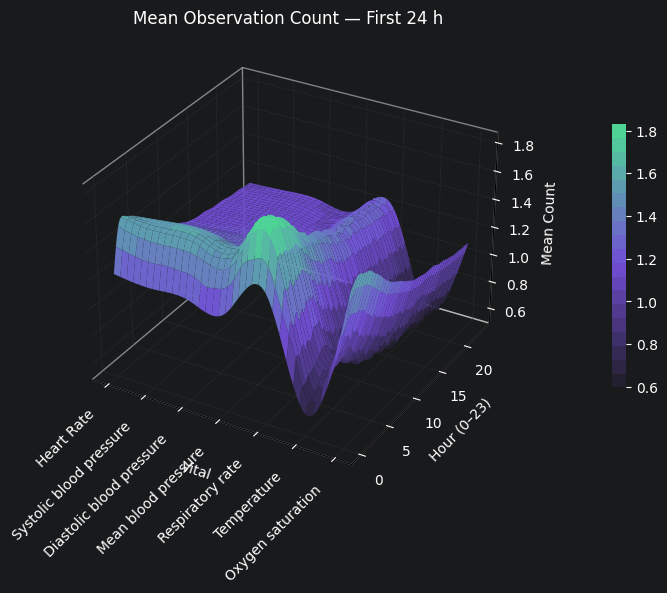

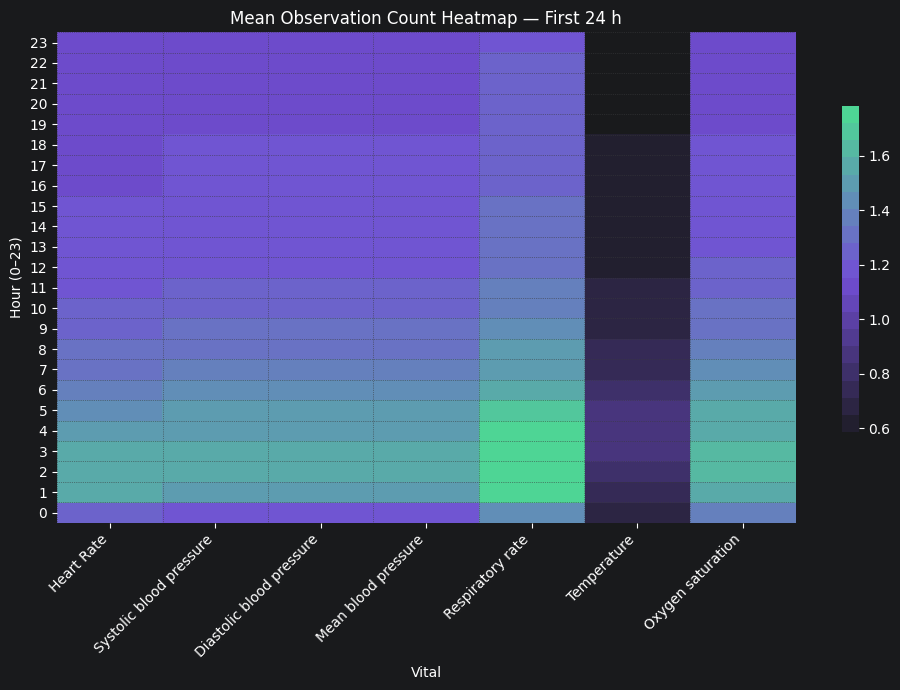

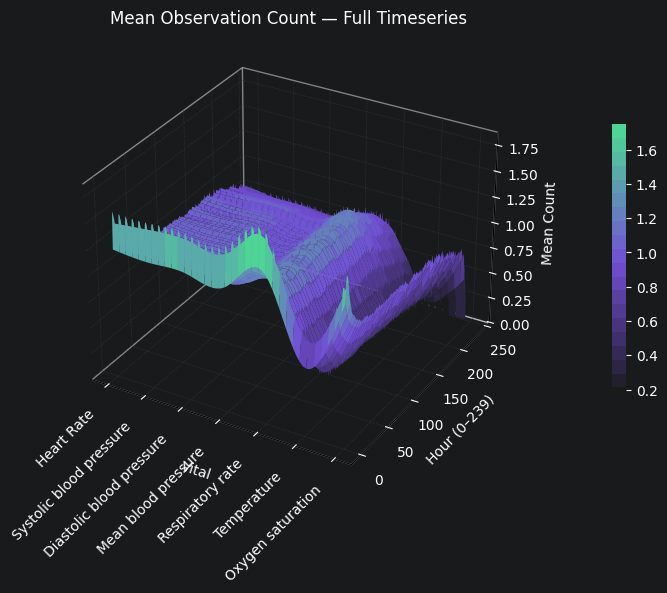

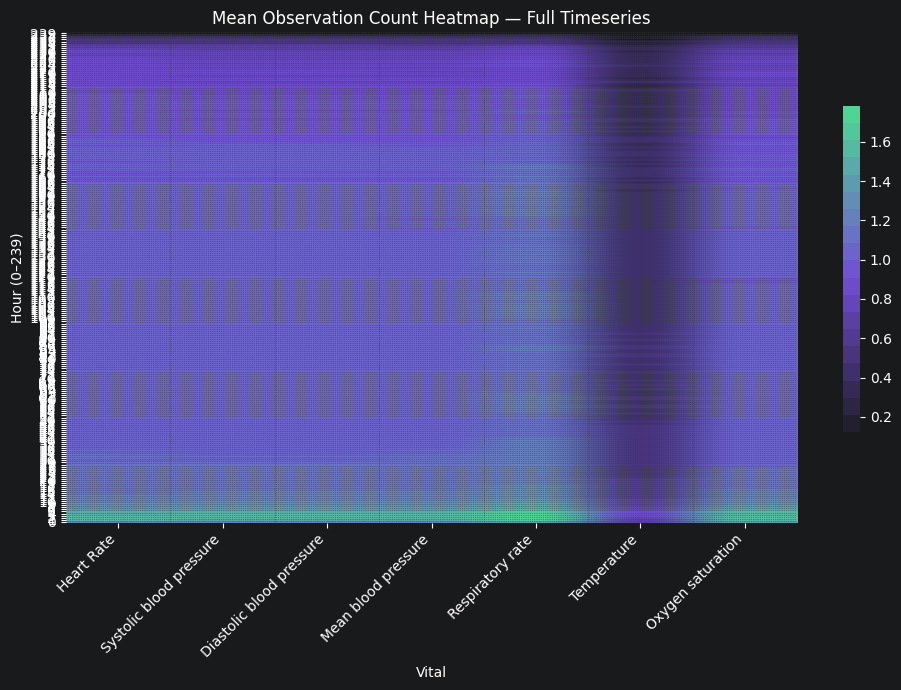


=== MEDIAN ===


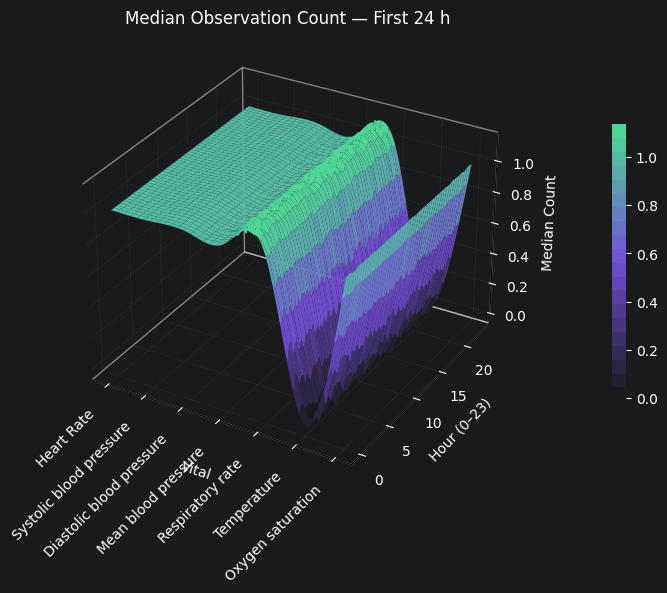

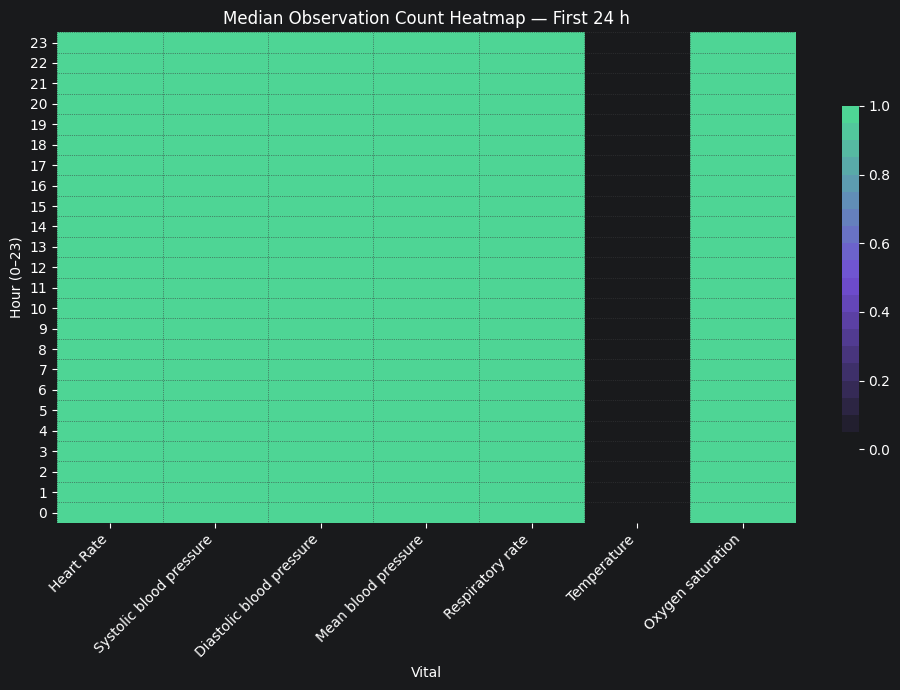

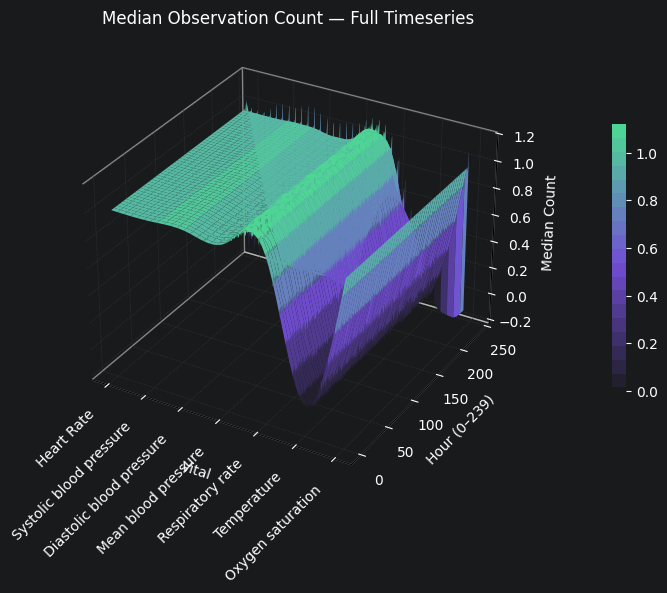

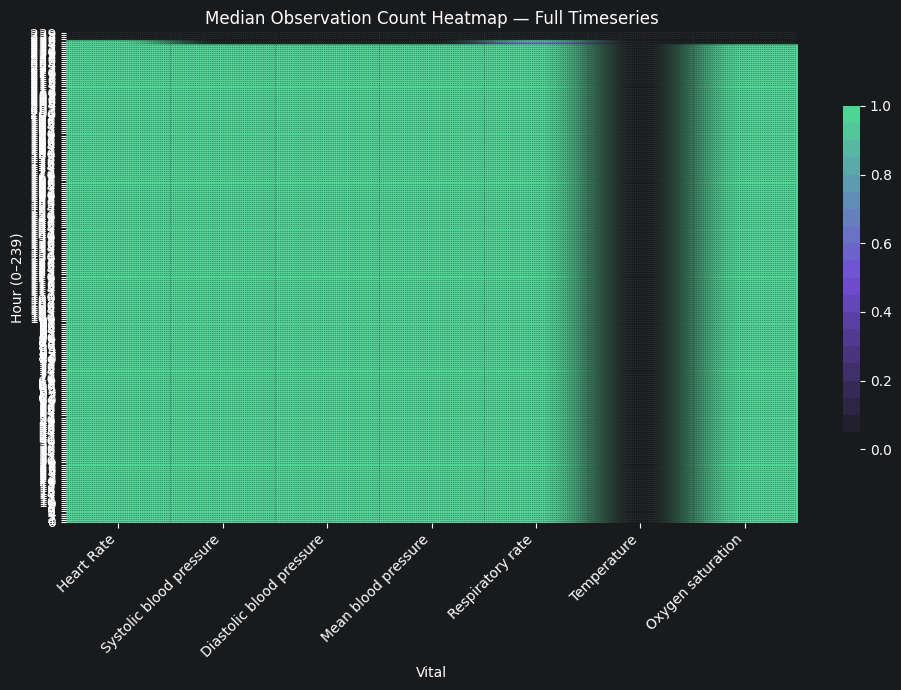


=== STD ===


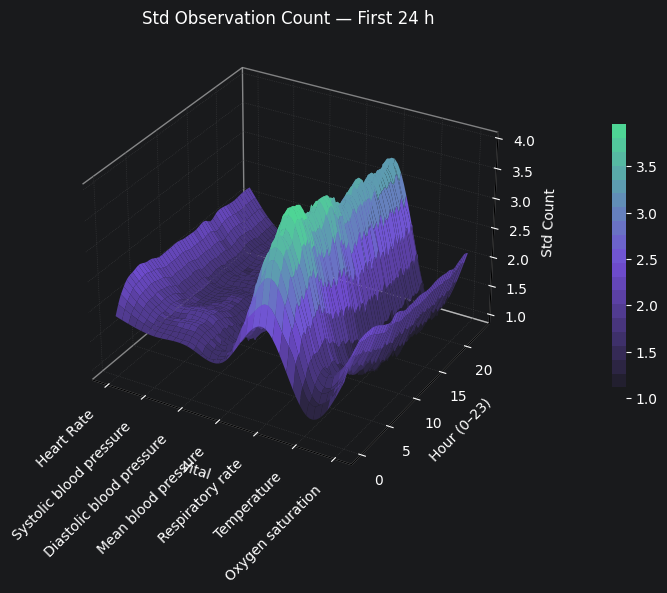

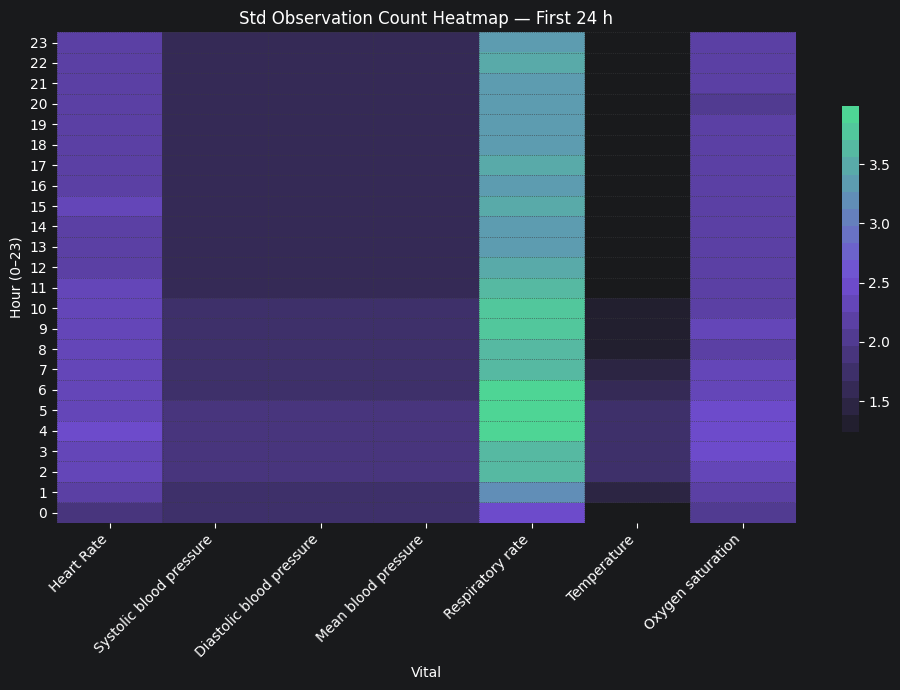

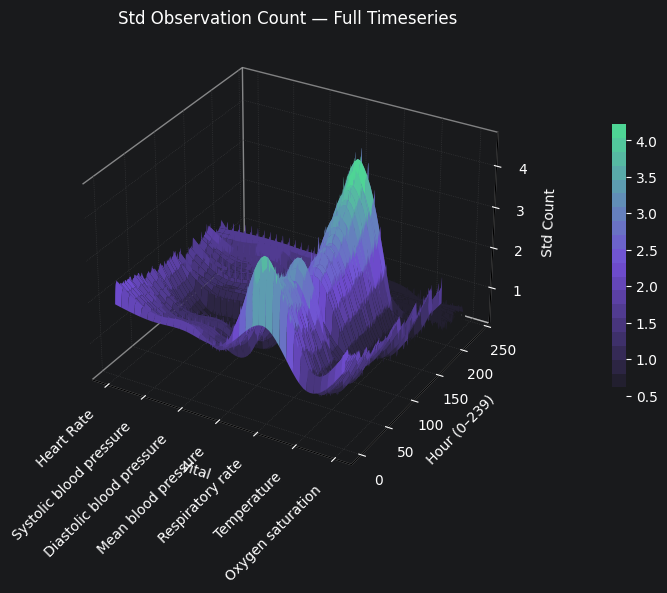

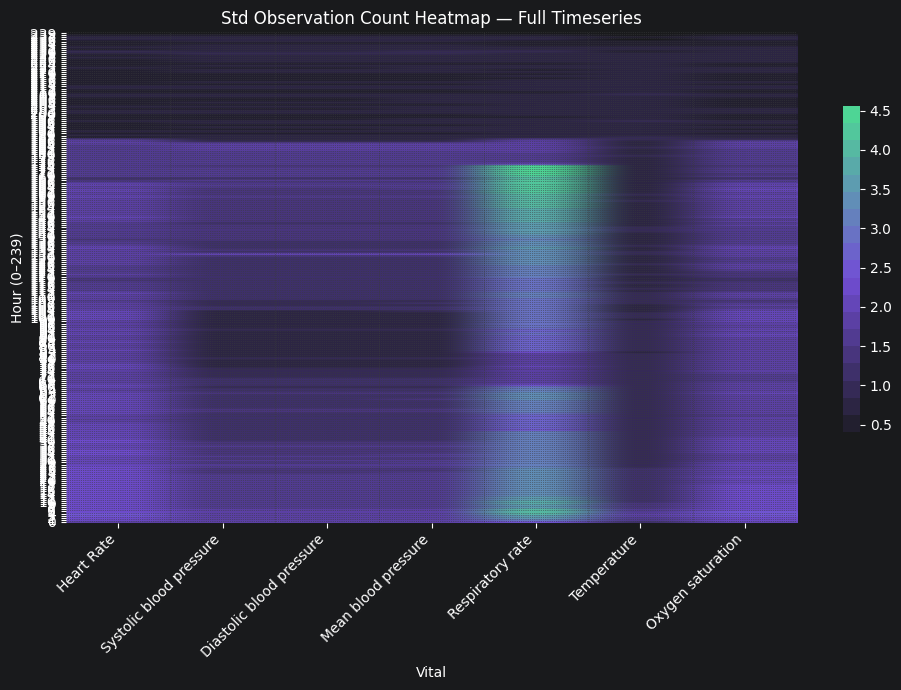


=== MAX ===


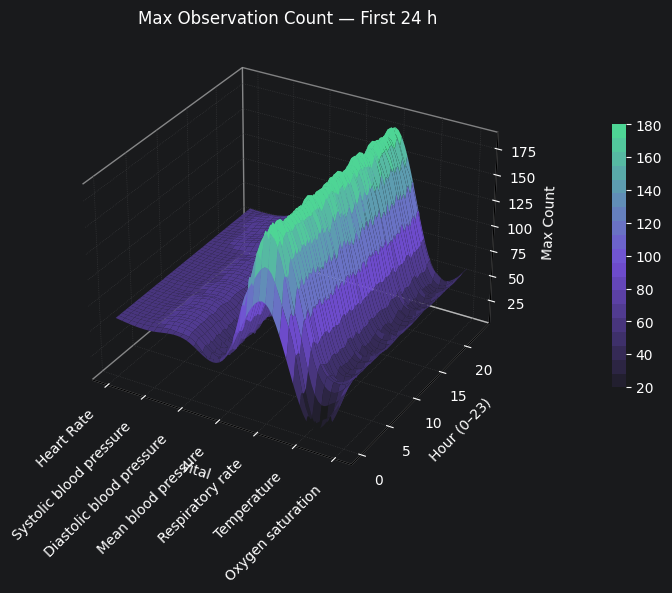

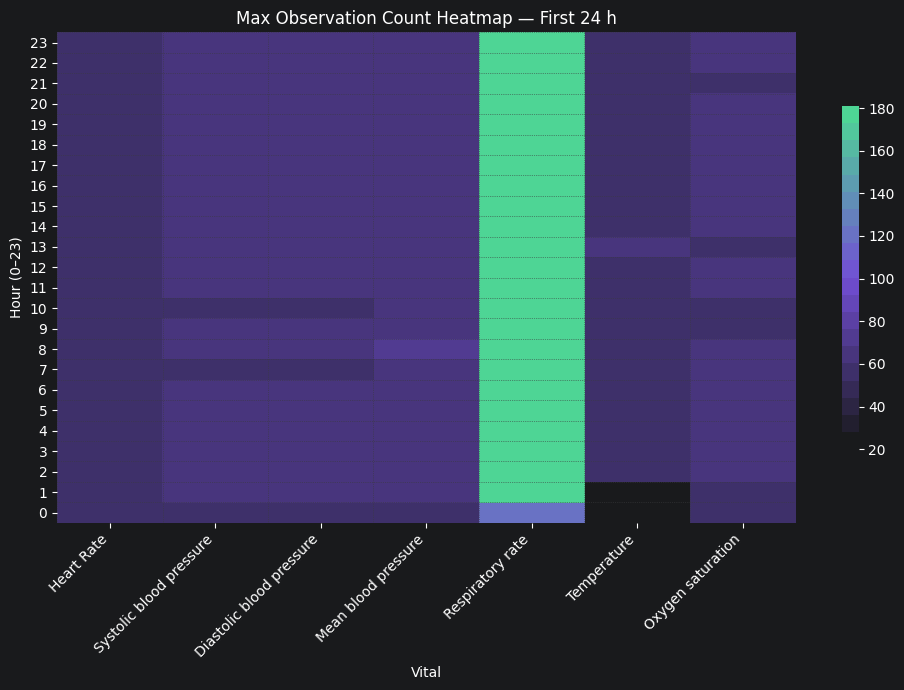

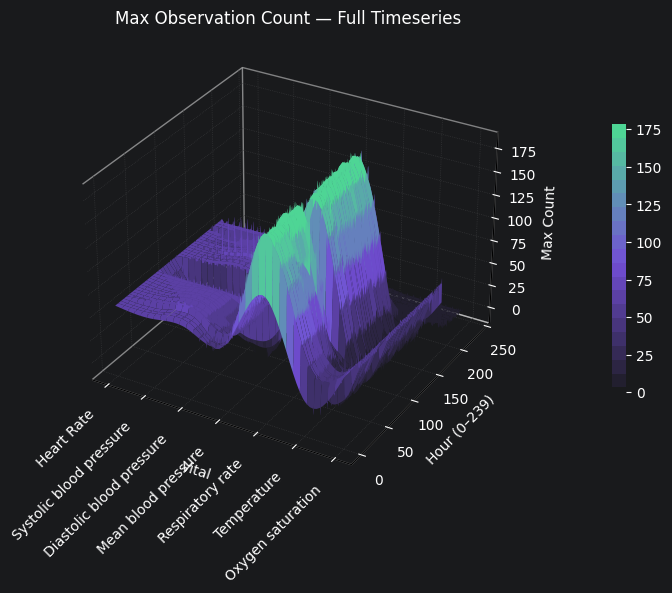

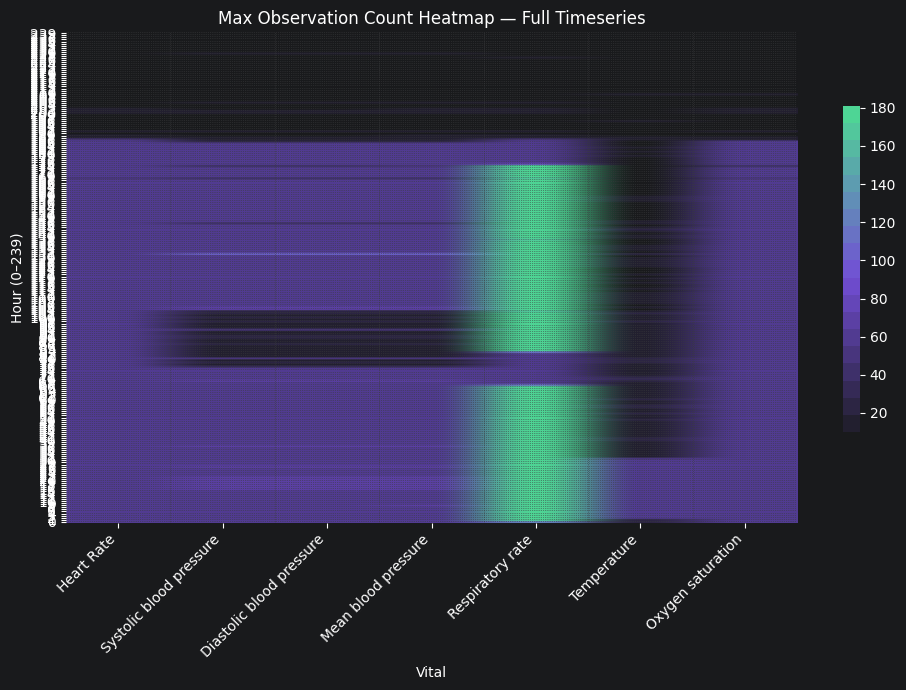


=== MIN ===


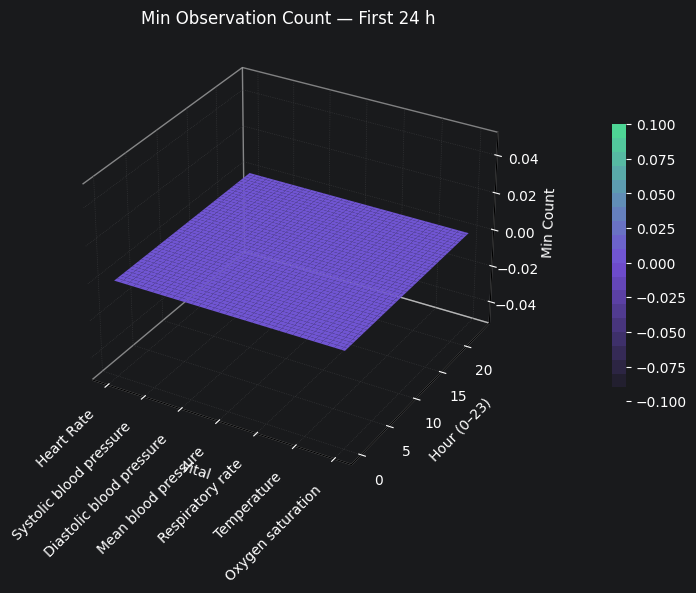

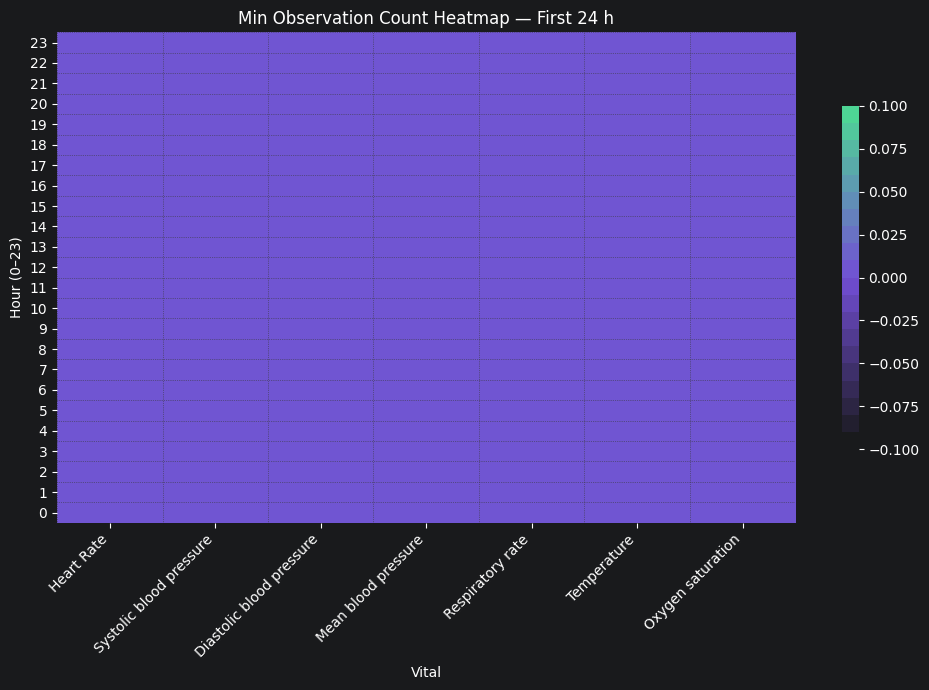

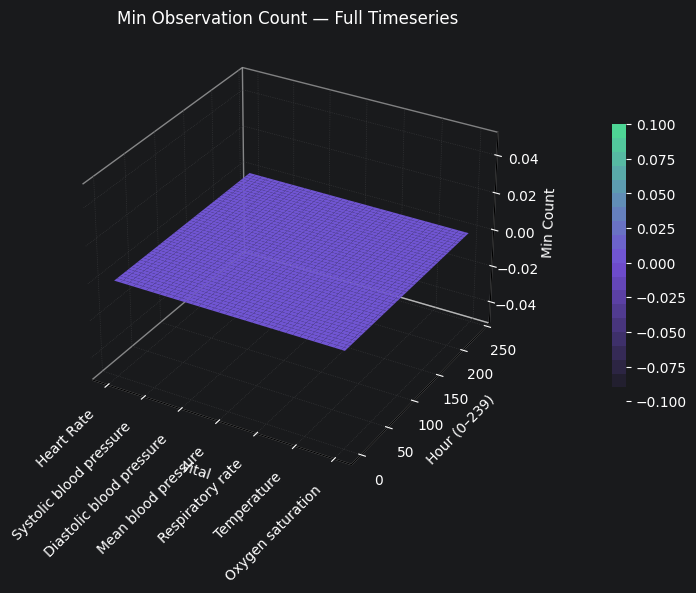

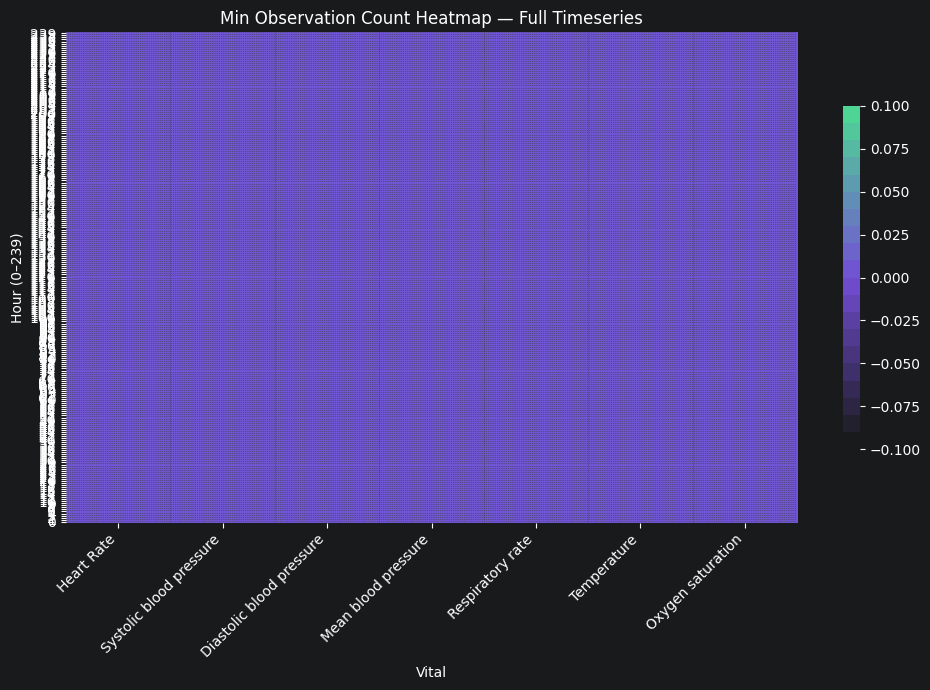

In [8]:
base_pat       = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
X_base_full_ts = subset_X_by_patients(BASELINE['X'], base_pat)

_time_level = _get_time_level_name(X_base_full_ts.index)
_hour_vals  = X_base_full_ts.index.get_level_values(_time_level)
X_base_24h  = X_base_full_ts[_hour_vals <= 23]

print(f"Full timeseries: hours {int(_hour_vals.min())}–{int(_hour_vals.max())} "
      f"({_hour_vals.nunique()} unique)")
print(f"24-hour subset : {len(X_base_24h):,} rows  |  Full: {len(X_base_full_ts):,} rows")

lengths_24h  = build_vital_hour_length_matrix(X_base_24h,  VITAL_NAMES)
lengths_full = build_vital_hour_length_matrix(X_base_full_ts, VITAL_NAMES)

LENGTH_METHODS = ['mean', 'median', 'std', 'max', 'min']
for method in LENGTH_METHODS:
    print(f'\n=== {method.upper()} ===')

    # ── 24-hour plots ──────────────────────────────────────────────────────────────────────
    df_24 = lengths_24h[method].fillna(0.0)
    generate_3d_plot(
        df_24,
        title=f'{method.capitalize()} Observation Count — First 24 h',
        x_title='Vital', y_title='Hour (0–23)',
        z_title=f'{method.capitalize()} Count',
    )
    generate_heatmap(
        df_24,
        title=f'{method.capitalize()} Observation Count Heatmap — First 24 h',
        x_title='Vital', y_title='Hour (0–23)',
        annotate=False,
    )

    # ── Full-timeseries plots ────────────────────────────────────────────────────────────────────────────────────
    df_full = lengths_full[method].fillna(0.0)
    generate_3d_plot(
        df_full,
        title=f'{method.capitalize()} Observation Count — Full Timeseries',
        x_title='Vital', y_title='Hour (0–239)',
        z_title=f'{method.capitalize()} Count',
    )
    generate_heatmap(
        df_full,
        title=f'{method.capitalize()} Observation Count Heatmap — Full Timeseries',
        x_title='Vital', y_title='Hour (0–239)',
        annotate=False,
    )


# Evaluating Scenario Impact for ICU and Mortality Tasks

For each `(aggregation_method, target_label)` pair:
1. Aggregate baseline records → train logistic regression (4 seeds).
2. For each variant, re-train and replay the baseline classifier on shared test patients.
3. Pool McNemar discordant counts across seeds to test statistical significance.

Results are cached under `data/scenario_analysis/`.

In [9]:
def evaluate_for_method(method, target_label, max_variants=None):
    cache_dir = ANALYSIS_CACHE_DIR / method.replace(' ', '_')
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_file = cache_dir / f'{target_label}_scenario_impact.pkl'
    if cache_file.exists():
        print(f'Loading cached results: {cache_file}')
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    base_pat    = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
    y_base      = _select_pos_label(base_pat, target_label)
    X_base_full = BASELINE['X']
    X_base_sm   = subset_X_by_patients(X_base_full, base_pat)
    X_base_agg  = build_record_aggregated_features(X_base_sm, method).loc[base_pat.index]
    base_cols   = X_base_agg.columns

    raw_metrics     = {'train_acc': [], 'test_acc': [], 'train_f1': [], 'test_f1': []}
    raw_preds_by_seed  = {}
    raw_models_by_seed = {}

    idx = X_base_agg.index
    for seed in SEEDS:
        train_ids, test_ids = train_test_split(
            idx, test_size=TEST_SIZE, random_state=seed,
            stratify=y_base.loc[idx].values)
        train_ids = _ensure_multiindex(train_ids, idx.names)
        test_ids  = _ensure_multiindex(test_ids,  idx.names)
        X_tr, X_te   = X_base_agg.loc[train_ids], X_base_agg.loc[test_ids]
        y_tr, y_te   = y_base.loc[train_ids].values, y_base.loc[test_ids].values
        if len(np.unique(y_tr)) < 2:
            continue
        X_trs, scaler, col_means = impute_and_scale(X_tr)
        X_te_f = X_te.replace([np.inf, -np.inf], np.nan).fillna(col_means).fillna(0.0)
        X_tes  = scaler.transform(X_te_f.values)
        clf    = LogisticRegression(**MODEL_KWARGS)
        clf.fit(X_trs, y_tr)
        raw_metrics['train_acc'].append(accuracy_score(y_tr, clf.predict(X_trs)))
        raw_metrics['test_acc' ].append(accuracy_score(y_te, clf.predict(X_tes)))
        raw_metrics['train_f1' ].append(f1_score(y_tr, clf.predict(X_trs), zero_division=0))
        raw_metrics['test_f1'  ].append(f1_score(y_te, clf.predict(X_tes), zero_division=0))
        raw_preds_by_seed[seed]  = (test_ids, clf.predict(X_tes), y_te)
        raw_models_by_seed[seed] = (clf, scaler, col_means, base_cols)

    results = {'raw': {
        'train_acc': float(np.mean(raw_metrics['train_acc'])),
        'test_acc':  float(np.mean(raw_metrics['test_acc'])),
        'train_f1':  float(np.mean(raw_metrics['train_f1'])),
        'test_f1':   float(np.mean(raw_metrics['test_f1'])),
        'mcnemar': None,
    }}

    variants = VARIANT_OBJS if max_variants is None else VARIANT_OBJS[:max_variants]
    for v in tqdm(variants, desc=f'{method}/{target_label}'):
        v_pat  = maybe_sample_record_ids(v['patients'], MAX_RECORDS_PER_SCENARIO)
        y_v    = _select_pos_label(v_pat, target_label)
        X_vf   = v.get('X') or pd.read_hdf(str(v['datafile']), 'vitals_labs')
        X_vsm  = subset_X_by_patients(X_vf, v_pat)
        X_vagg = build_record_aggregated_features(X_vsm, method).loc[v_pat.index]
        metrics  = {'train_acc': [], 'test_acc': [], 'train_f1': [], 'test_f1': []}
        base_int = {'acc': [], 'f1': []}
        n01_tot = n10_tot = 0
        for seed in SEEDS:
            base_test_ids, _, _ = raw_preds_by_seed[seed]
            tids = v_pat.index.intersection(base_test_ids)
            if len(tids) < 10:
                continue
            trids = v_pat.index.difference(tids)
            if len(trids) < 10:
                continue
            X_tr, X_te = X_vagg.loc[trids], X_vagg.loc[tids]
            y_tr, y_te = y_v.loc[trids].values, y_v.loc[tids].values
            if len(np.unique(y_tr)) < 2:
                continue
            X_trs, scaler, cm = impute_and_scale(X_tr)
            X_tef = X_te.replace([np.inf, -np.inf], np.nan).fillna(cm).fillna(0.0)
            X_tes = scaler.transform(X_tef.values)
            clf   = LogisticRegression(**MODEL_KWARGS)
            clf.fit(X_trs, y_tr)
            pred_te_var = clf.predict(X_tes)
            metrics['train_acc'].append(accuracy_score(y_tr, clf.predict(X_trs)))
            metrics['test_acc' ].append(accuracy_score(y_te, pred_te_var))
            metrics['train_f1' ].append(f1_score(y_tr, clf.predict(X_trs), zero_division=0))
            metrics['test_f1'  ].append(f1_score(y_te, pred_te_var, zero_division=0))
            base_clf, base_sc, base_cm, bsc = raw_models_by_seed[seed]
            X_teb  = X_base_agg.loc[tids, bsc]
            X_tebf = X_teb.replace([np.inf, -np.inf], np.nan).fillna(base_cm).fillna(0.0)
            bp     = base_clf.predict(base_sc.transform(X_tebf.values))
            base_int['acc'].append(accuracy_score(y_te, bp))
            base_int['f1' ].append(f1_score(y_te, bp, zero_division=0))
            n01, n10 = mcnemar_counts(y_te, bp, pred_te_var)
            n01_tot += n01;  n10_tot += n10
        mc = (mcnemar_pooled(n01_tot, n10_tot) + (n01_tot, n10_tot)) if metrics['test_acc'] else (np.nan, np.nan, 0, 0)
        results[v['name']] = {
            'train_acc': float(np.mean(metrics['train_acc'])) if metrics['train_acc'] else np.nan,
            'test_acc' : float(np.mean(metrics['test_acc']))  if metrics['test_acc']  else np.nan,
            'train_f1' : float(np.mean(metrics['train_f1']))  if metrics['train_f1']  else np.nan,
            'test_f1'  : float(np.mean(metrics['test_f1']))   if metrics['test_f1']   else np.nan,
            'baseline_acc_on_var_test': float(np.mean(base_int['acc'])) if base_int['acc'] else np.nan,
            'baseline_f1_on_var_test' : float(np.mean(base_int['f1']))  if base_int['f1']  else np.nan,
            'mcnemar': mc,
        }
        try:
            del X_vf, X_vsm, X_vagg
        except Exception:
            pass

    with open(cache_file, 'wb') as f:
        pickle.dump(results, f)
    print(f'Saved cache: {cache_file}')
    return results


# ── run full sweep ─────────────────────────────────────────────────────────────
SCENARIO_IMPACT_RESULTS = {}
for _label in LABELS:
    SCENARIO_IMPACT_RESULTS[_label] = {}
    for _method in AGG_METHODS:
        res = evaluate_for_method(_method, _label)
        SCENARIO_IMPACT_RESULTS[_label][_method] = res
        names = ['raw'] + [n for n in res.keys() if n != 'raw']
        rows  = []
        for n in names:
            r = res[n]
            if n == 'raw' or r['mcnemar'] is None:
                mc_str = 'baseline reference'
            else:
                stat, p, n01, n10 = r['mcnemar']
                mc_str = f'{stat:.1f} (p={p:.3e}, n01={n01}, n10={n10})'
            rows.append([n, r['train_acc'], r['test_acc'], r['train_f1'], r['test_f1'], mc_str])
        print(f'\n{LABEL_DISPLAY[_label]} — {_method.capitalize()} aggregation')
        print(tabulate(rows, headers=['Scenario','Tr Acc','Te Acc','Tr F1','Te F1','McNemar'],
                       tablefmt='github', floatfmt='.4f'))


Loading cached results: ../data/scenario_analysis/mean/icu_los_scenario_impact.pkl

icu_los (ICU stay > 3 days) — Mean aggregation
| Scenario      |   Tr Acc |   Te Acc |   Tr F1 |   Te F1 | McNemar                                  |
|---------------|----------|----------|---------|---------|------------------------------------------|
| raw           |   0.7041 |   0.7029 |  0.1737 |  0.1698 | baseline reference                       |
| age35_range5  |   0.7878 |   0.7851 |  0.4139 |  0.4001 | 0.0 (p=1.000e+00, n01=21, n10=20)        |
| age35_range10 |   0.7699 |   0.7745 |  0.2164 |  0.2483 | 0.0 (p=1.000e+00, n01=27, n10=26)        |
| age35_range15 |   0.7663 |   0.7604 |  0.1950 |  0.1988 | 1.0 (p=3.082e-01, n01=34, n10=44)        |
| age45_range5  |   0.7550 |   0.7517 |  0.2752 |  0.2297 | 1.6 (p=2.074e-01, n01=37, n10=26)        |
| age45_range10 |   0.7529 |   0.7424 |  0.2262 |  0.1983 | 0.2 (p=6.241e-01, n01=55, n10=49)        |
| age45_range15 |   0.7442 |   0.7361 |  0.21

Loading cached results: ../data/scenario_analysis/standard_deviation/mortality_scenario_impact.pkl

mort_hosp / hospital_expire_flag  (hospital mortality) — Standard deviation aggregation
| Scenario      |   Tr Acc |   Te Acc |   Tr F1 |   Te F1 | McNemar                           |
|---------------|----------|----------|---------|---------|-----------------------------------|
| raw           |   0.9266 |   0.9256 |  0.4481 |  0.4397 | baseline reference                |
| age35_range5  |   0.9689 |   0.9672 |  0.4405 |  0.2887 | 0.0 (p=1.000e+00, n01=4, n10=3)   |
| age35_range10 |   0.9663 |   0.9646 |  0.4425 |  0.4124 | 0.9 (p=3.438e-01, n01=7, n10=3)   |
| age35_range15 |   0.9635 |   0.9628 |  0.3713 |  0.3979 | 0.1 (p=1.000e+00, n01=10, n10=10) |
| age45_range5  |   0.9614 |   0.9618 |  0.5167 |  0.5152 | 0.0 (p=1.000e+00, n01=4, n10=5)   |
| age45_range10 |   0.9534 |   0.9542 |  0.4250 |  0.4153 | 13.1 (p=1.211e-04, n01=2, n10=20) |
| age45_range15 |   0.9529 |   0.9548 |  0.4

# Scenario Impact Ranking

Rank each variant by accuracy Δ, F1 Δ, and McNemar p-value across all aggregation methods and labels.

In [10]:
SCENARIO_NAMES = [v['name'] for v in VARIANT_OBJS]

for _label in LABELS:
    for _method in AGG_METHODS:
        res    = SCENARIO_IMPACT_RESULTS[_label][_method]
        tup    = results_dict_to_impact_tuple(res)
        # deltas from baseline (index 0)
        acc_d  = np.array([x - tup[1][0] for x in tup[1][1:]])
        f1_d   = np.array([x - tup[3][0] for x in tup[3][1:]])
        pvals  = [t[1] for t in tup[4][1:]]

        safe_p = [p if (p == p) else 1.0 for p in pvals]
        acc_rk = (np.argsort(np.argsort(-acc_d)) + 1).tolist()
        f1_rk  = (np.argsort(np.argsort(-f1_d))  + 1).tolist()
        p_rk   = (np.argsort(np.argsort(safe_p))  + 1).tolist()

        rows = [
            [SCENARIO_NAMES[i], f'{acc_d[i]:+.4f}', f'{f1_d[i]:+.4f}',
             f'{safe_p[i]:.3e}', acc_rk[i], f1_rk[i], p_rk[i]]
            for i in range(len(SCENARIO_NAMES))
        ]
        print(f'\n### {LABEL_DISPLAY[_label]} — {_method.capitalize()} Aggregation')
        print(tabulate(rows, headers=['Scenario','Acc Δ','F1 Δ','P-Value',
                                       'Acc Rank','F1 Rank','P Rank'],
                       tablefmt='github'))



### icu_los (ICU stay > 3 days) — Mean Aggregation
| Scenario      |   Acc Δ |    F1 Δ |    P-Value |   Acc Rank |   F1 Rank |   P Rank |
|---------------|---------|---------|------------|------------|-----------|----------|
| age35_range5  |  0.0822 |  0.2303 | 1          |          1 |         2 |       10 |
| age35_range10 |  0.0716 |  0.0785 | 1          |          2 |         4 |        9 |
| age35_range15 |  0.0575 |  0.029  | 0.3082     |          3 |         6 |        7 |
| age45_range5  |  0.0488 |  0.0599 | 0.2074     |          4 |         5 |        6 |
| age45_range10 |  0.0395 |  0.0285 | 0.6241     |          5 |         7 |        8 |
| age45_range15 |  0.0332 |  0.0191 | 0.04327    |          7 |         9 |        4 |
| age55_range5  |  0.0373 |  0.1017 | 0.005078   |          6 |         3 |        2 |
| age55_range10 |  0.0235 |  0.0093 | 0.01436    |          8 |        10 |        3 |
| age55_range15 |  0.0197 |  0.0227 | 0.05823    |          9 |         8 |   

# Scenario Impact Visualization

Aurora bar charts showing each scenario's accuracy / F1 deviation from the `baseline_nofilters` reference.

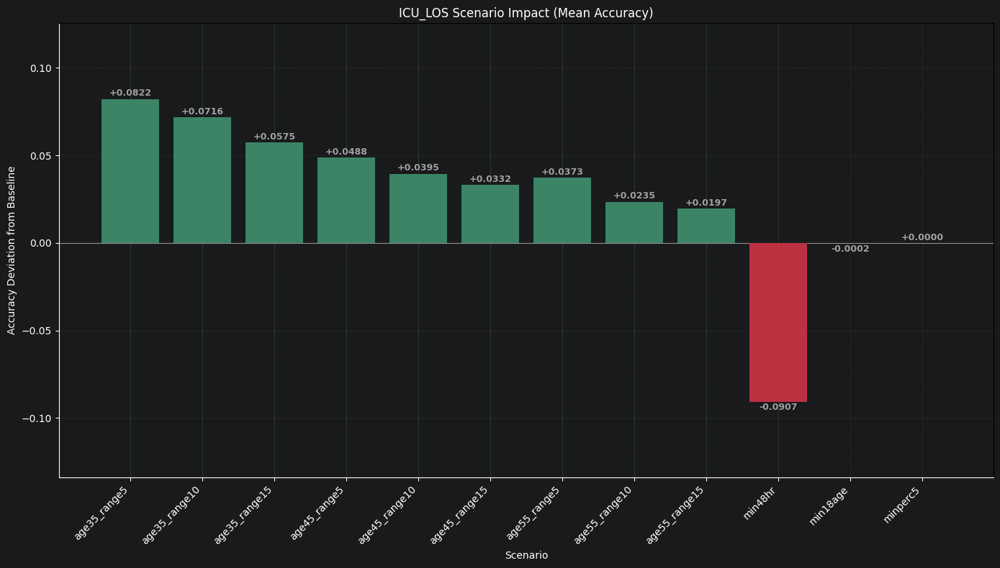

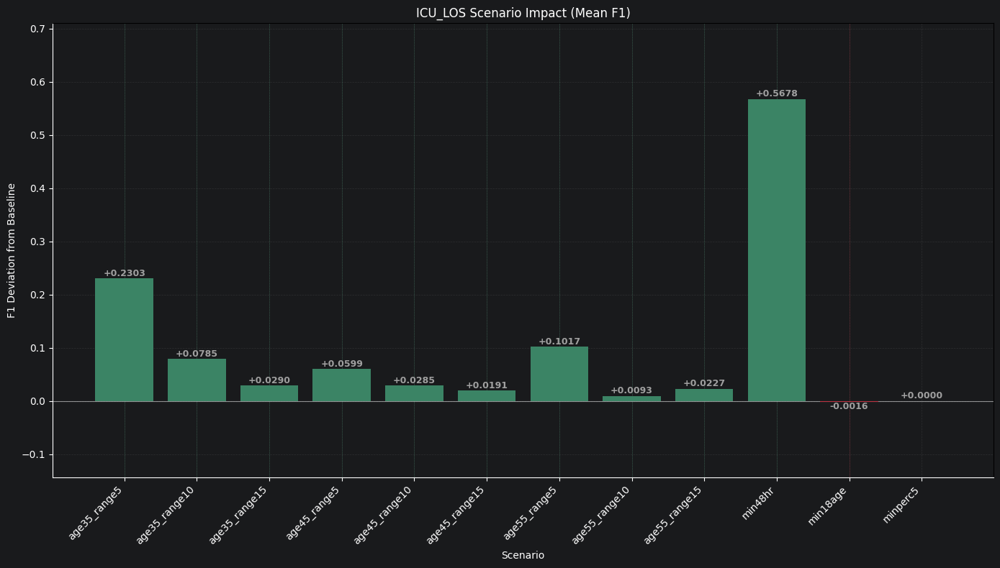

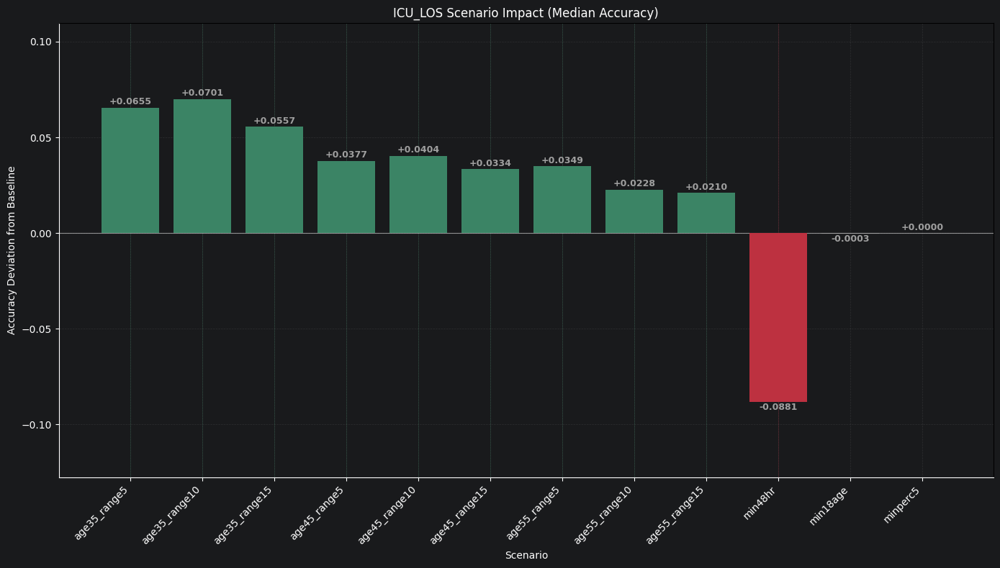

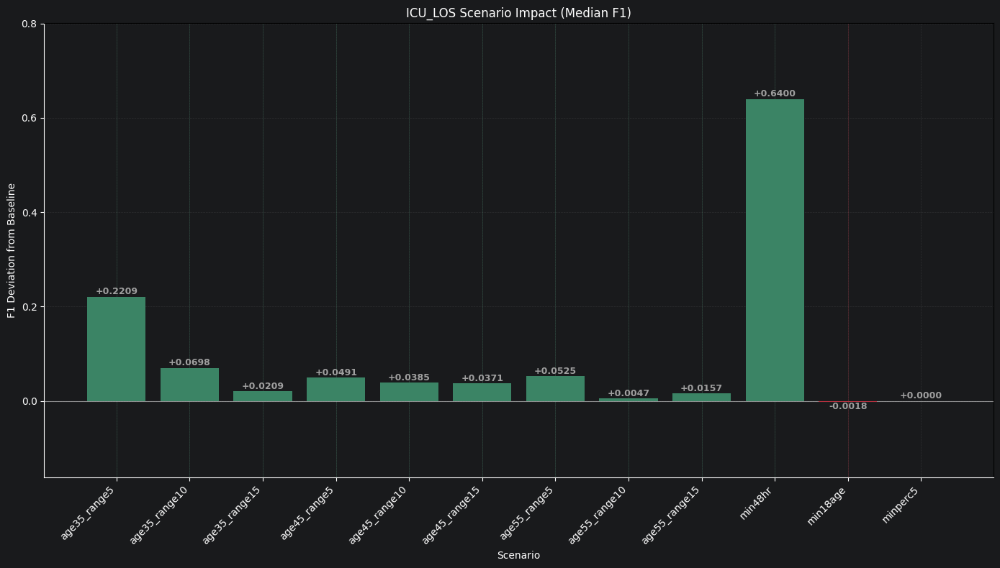

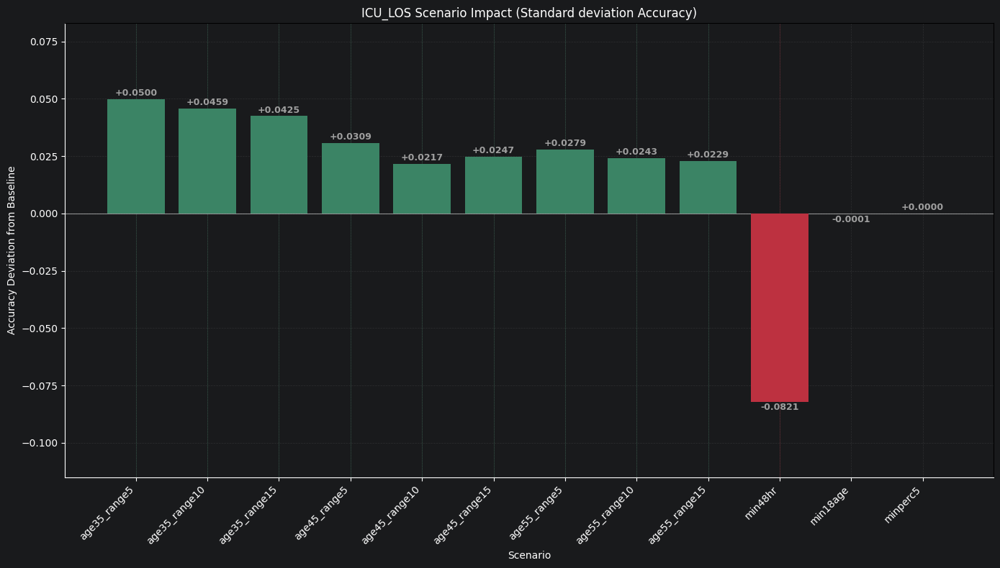

...

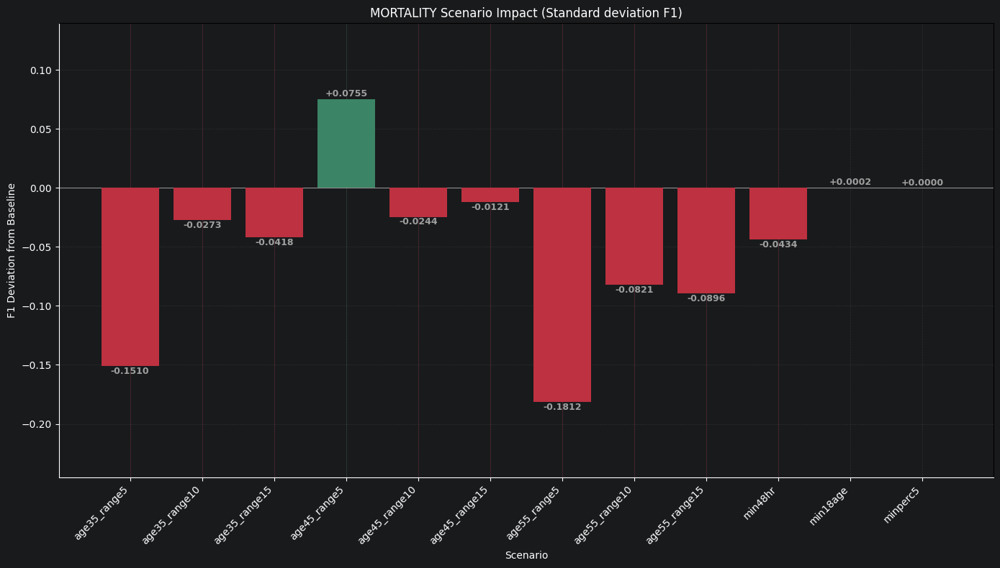

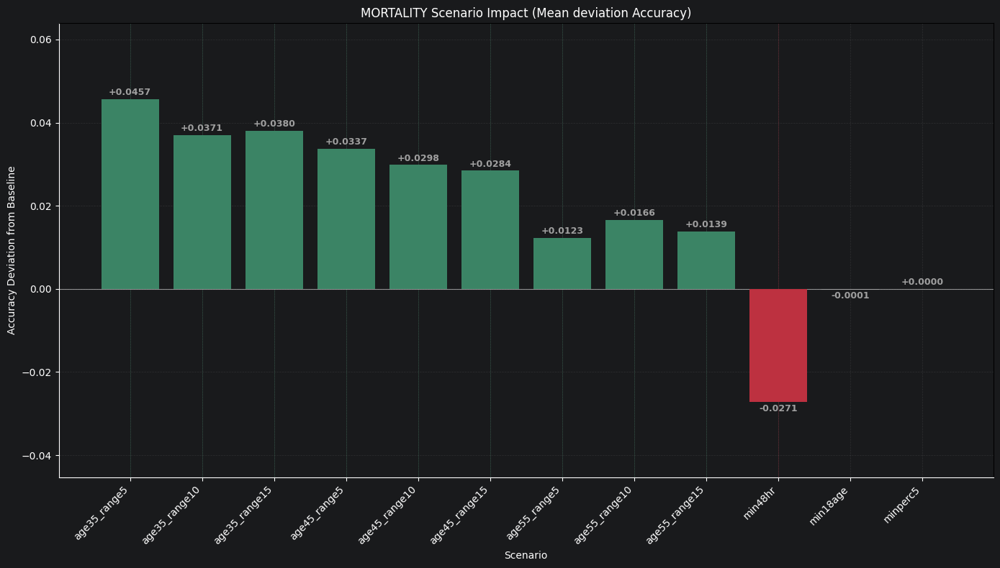

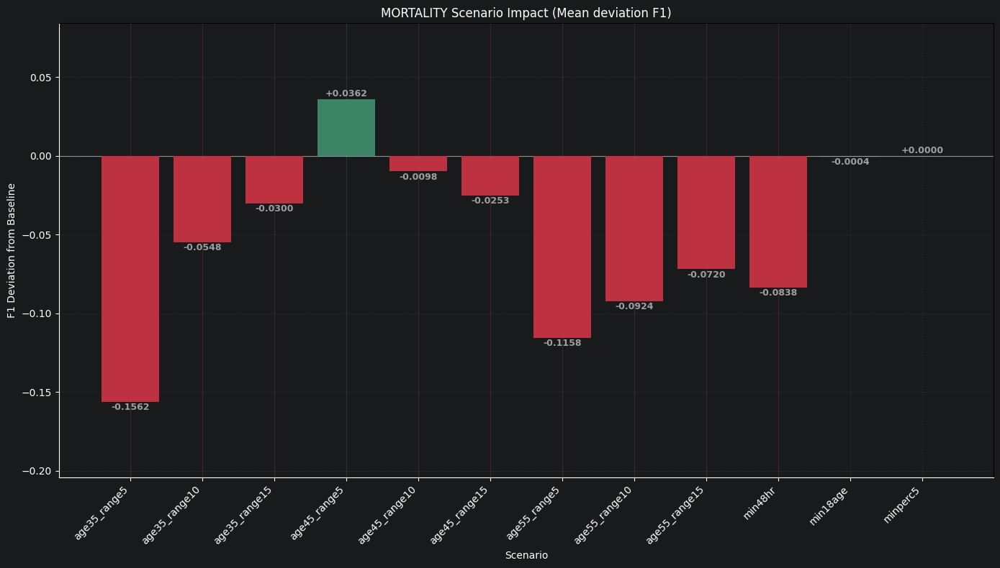

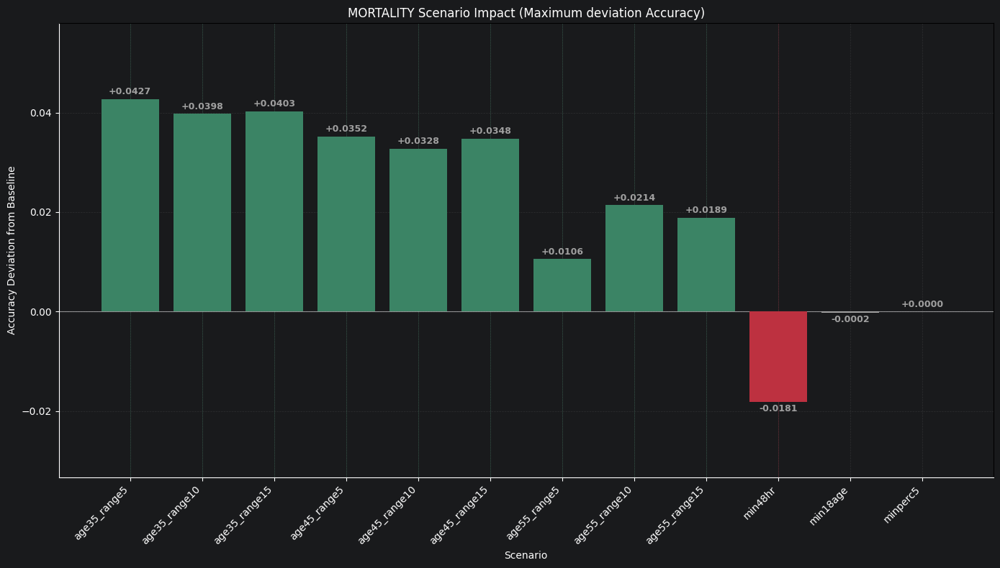

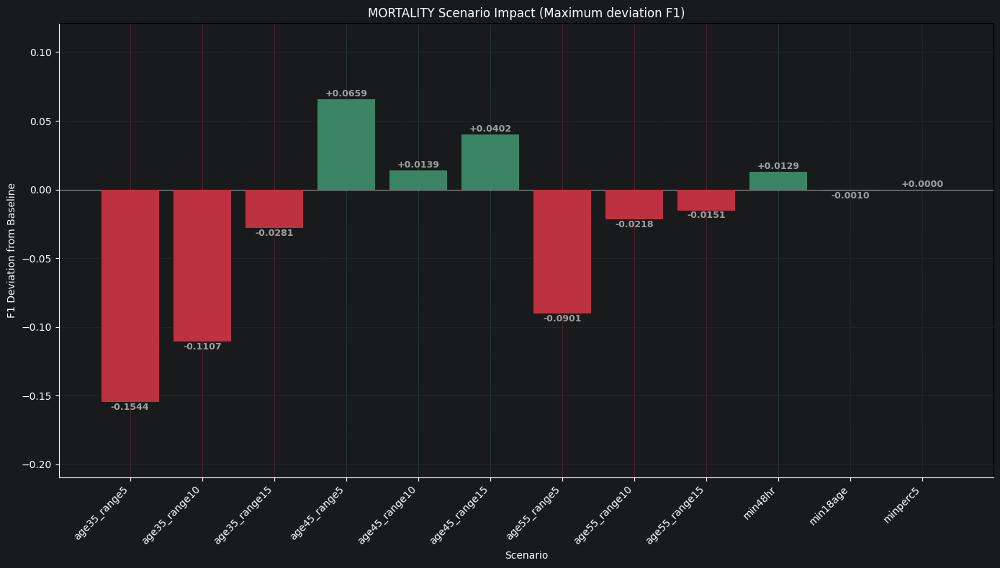

In [11]:
for _label in LABELS:
    for _method in AGG_METHODS:
        tup  = results_dict_to_impact_tuple(SCENARIO_IMPACT_RESULTS[_label][_method])
        for metric, scores in [('Accuracy', tup[1]), ('F1', tup[3])]:
            visualize_scenario_impact(scores, SCENARIO_NAMES,
                                      _label, metric, _method)


# McNemar Significance Visualization

Aurora bar charts of $-\\log_{10}(p)$ from McNemar's test (orange = significant at p < 0.05).

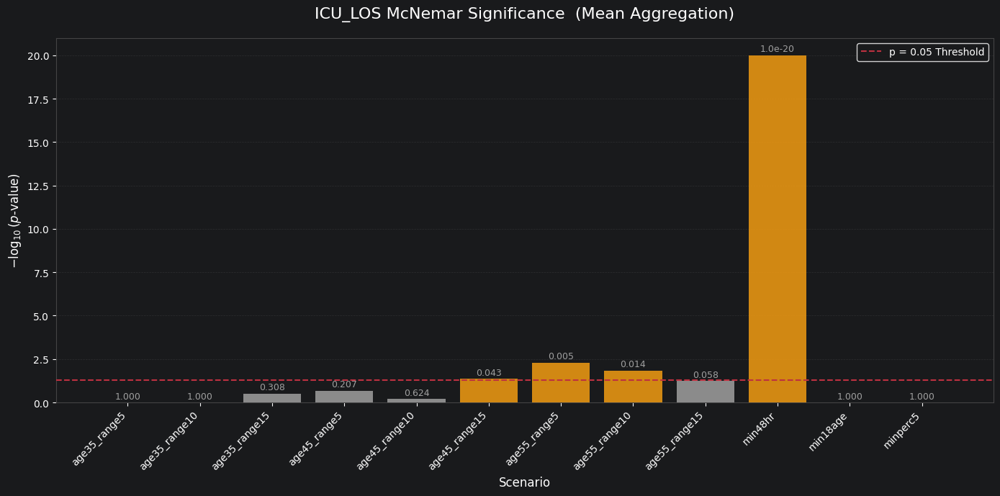

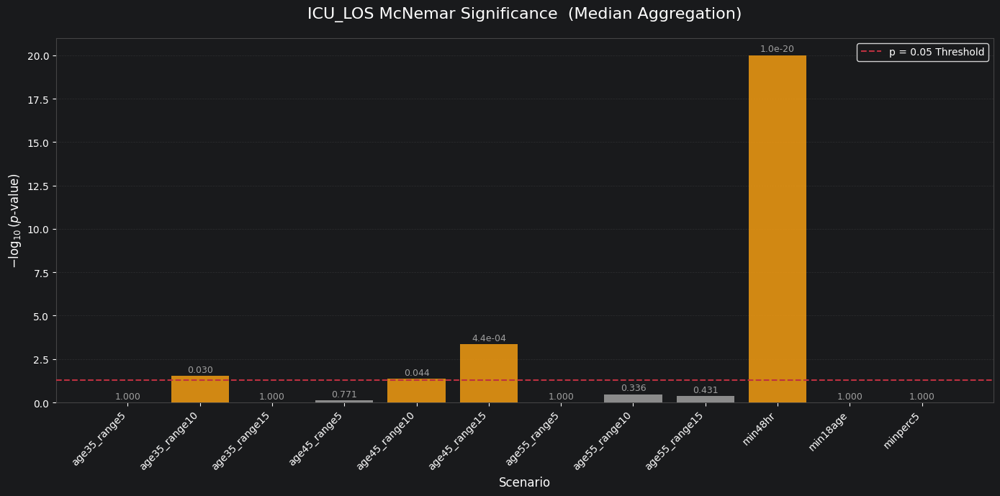

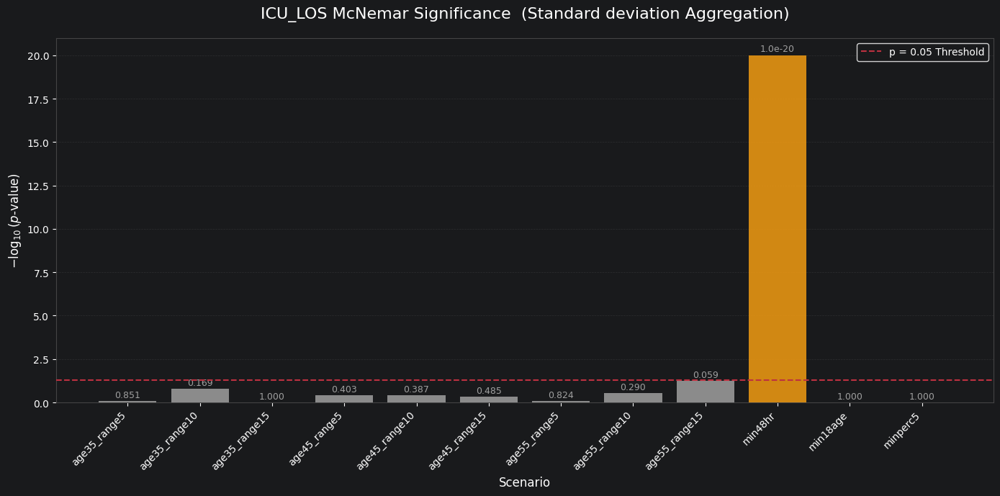

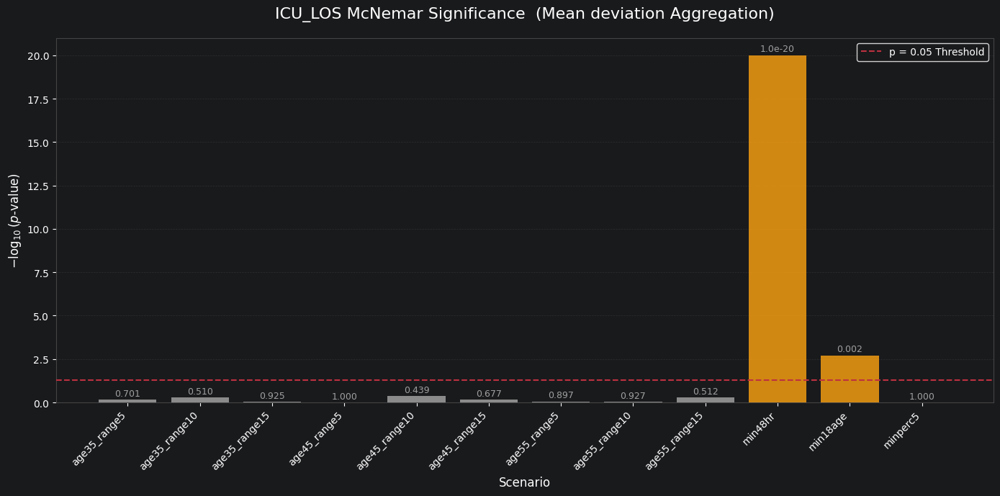

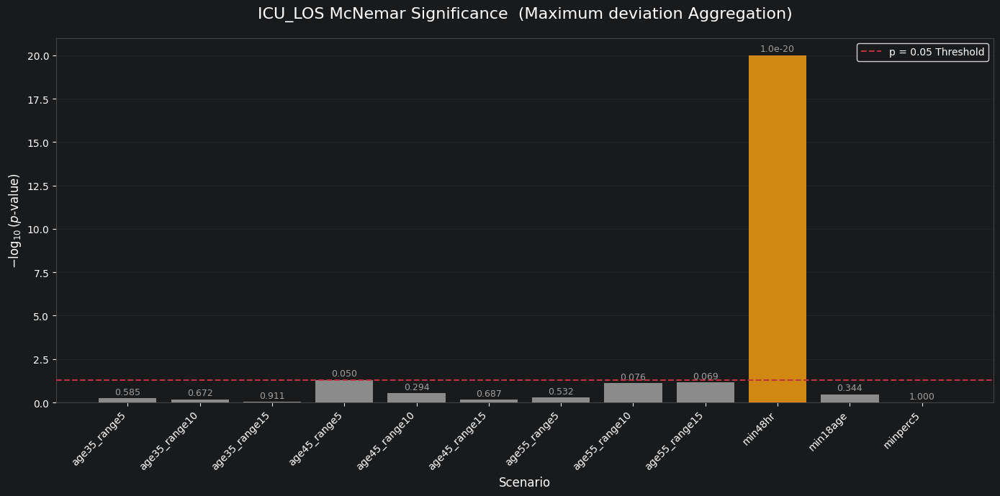

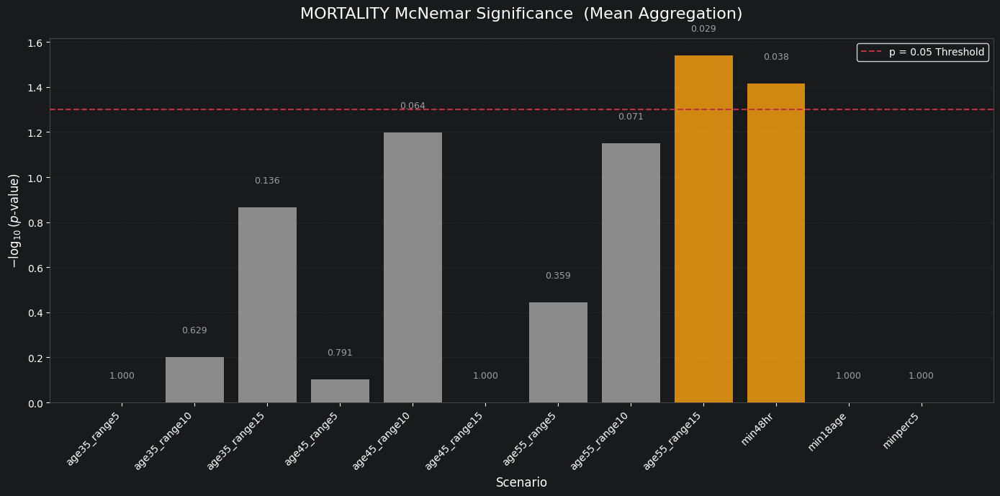

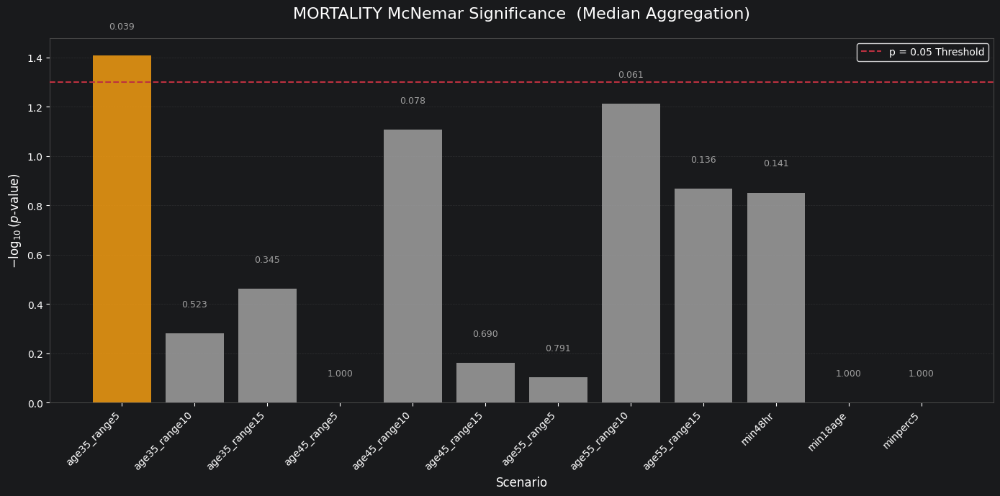

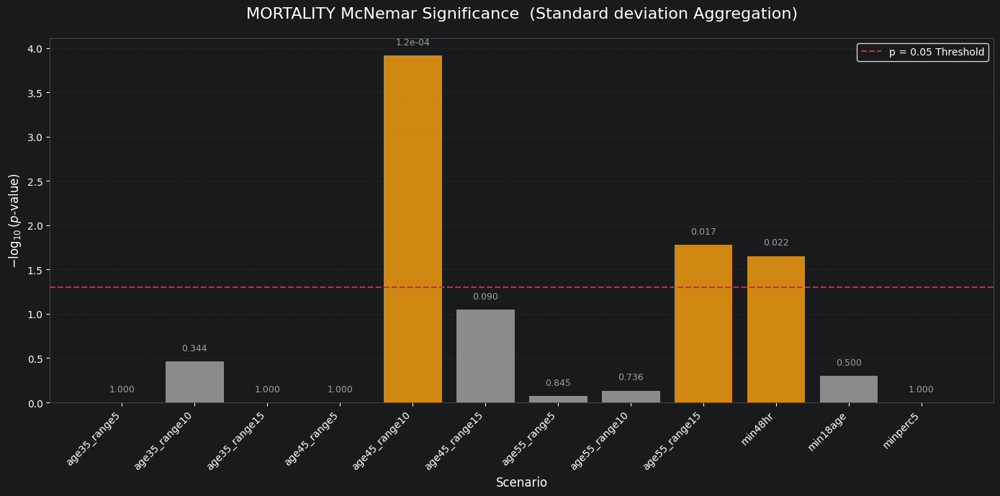

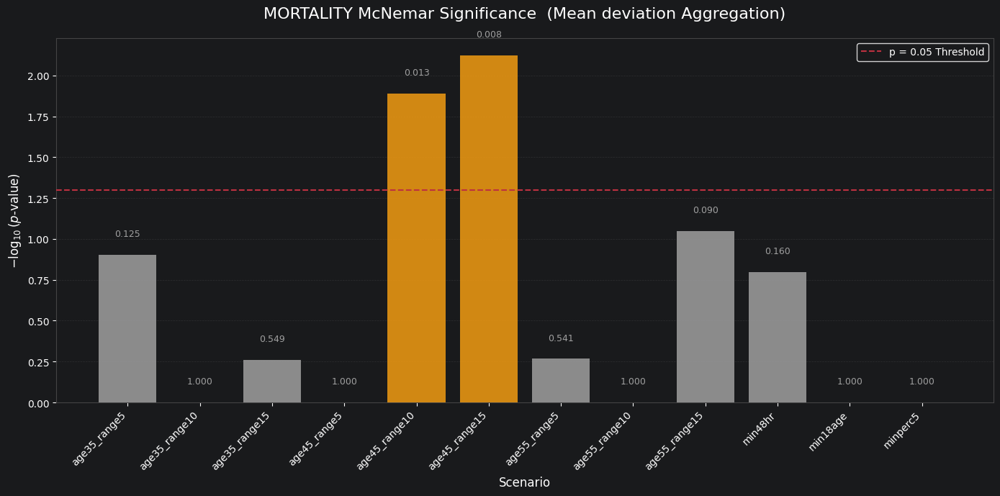

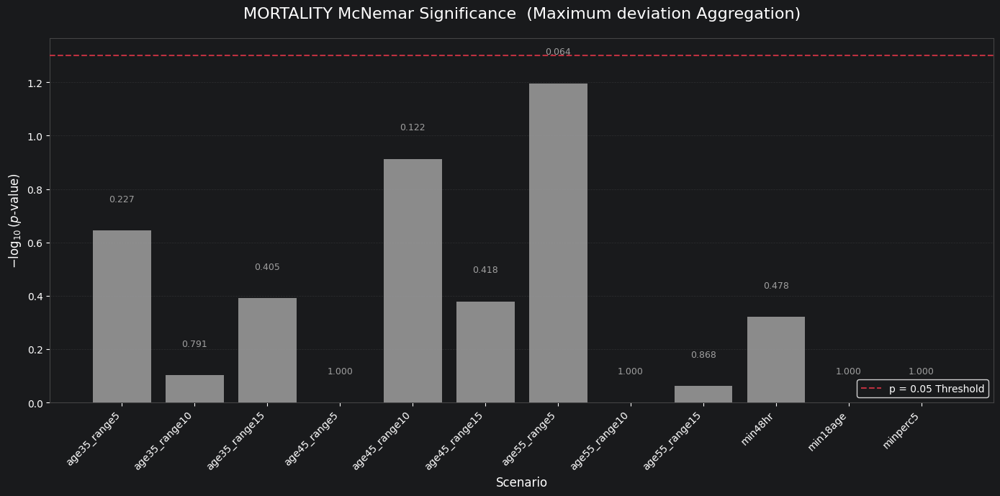

In [12]:
for _label in LABELS:
    for _method in AGG_METHODS:
        tup   = results_dict_to_impact_tuple(SCENARIO_IMPACT_RESULTS[_label][_method])
        pvals = [t[1] for t in tup[4][1:]]   # skip baseline (index 0)
        visualize_mcnemar_significance(
            pvals,
            SCENARIO_NAMES,
            _label,
            title=f'{_label.upper()} McNemar Significance  ({_method.capitalize()} Aggregation)',
        )


# Centroid Shift Analysis

Two views:
1. **Per-vital bar chart** (Aurora style) — deviation of each vital's mean centroid between baseline and variant, split by ICU+/ICU−/Mortality+/Mortality−.
2. **PCA scatter** — 2-D projection of full-feature centroid shift vectors.


=== Centroid shift bars: mean ===


mean centroid bars:   0%|          | 0/12 [00:00<?, ?it/s]

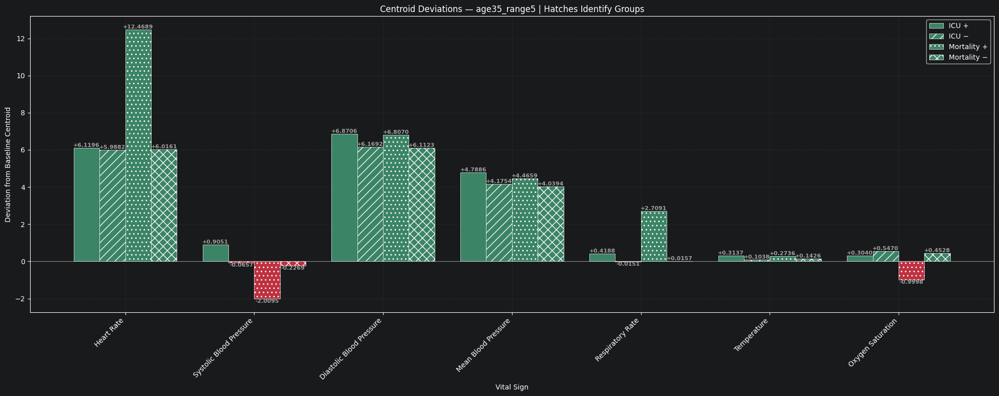

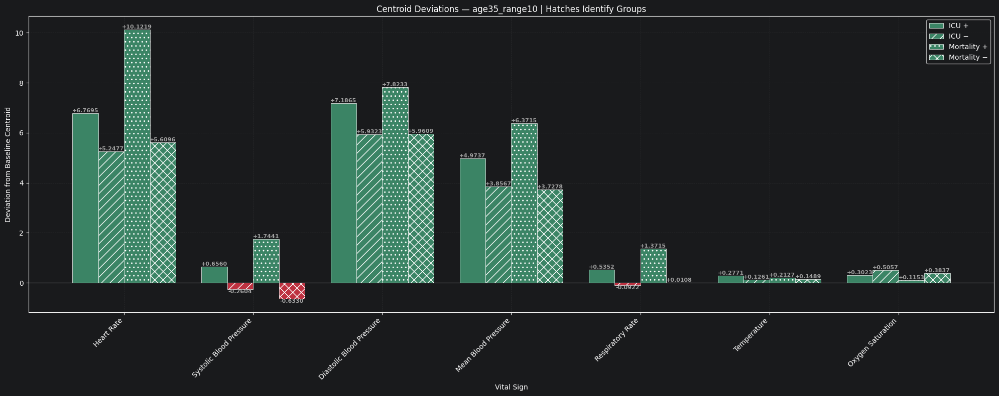

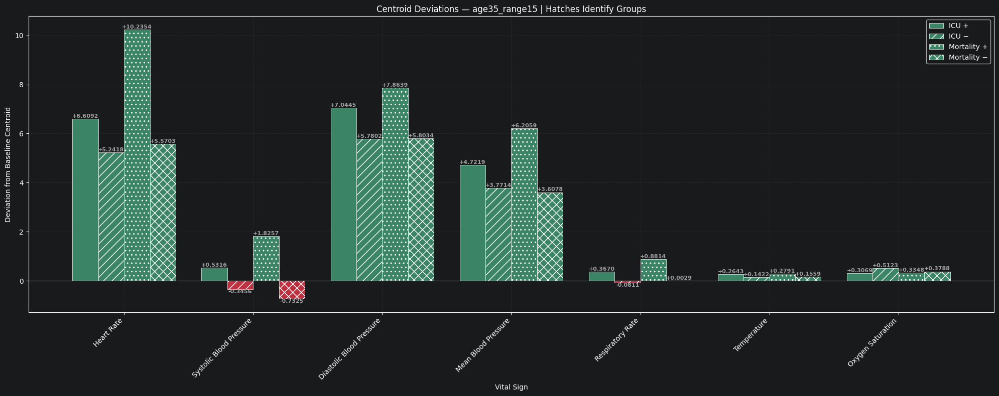

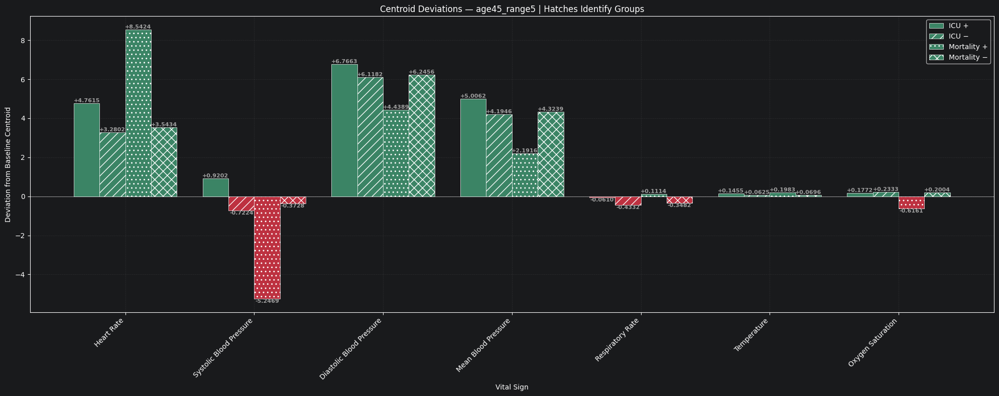

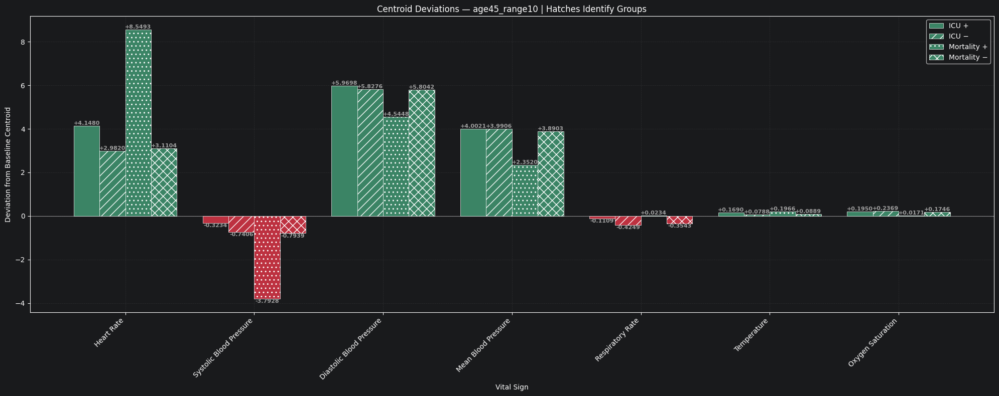

...

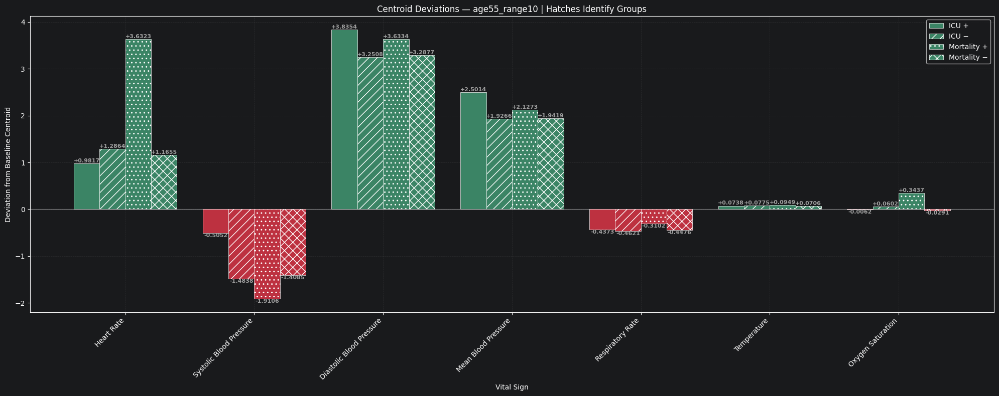

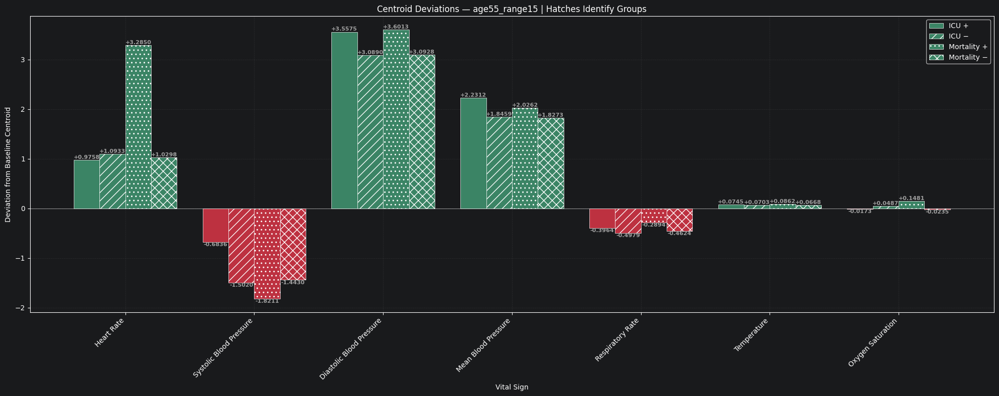

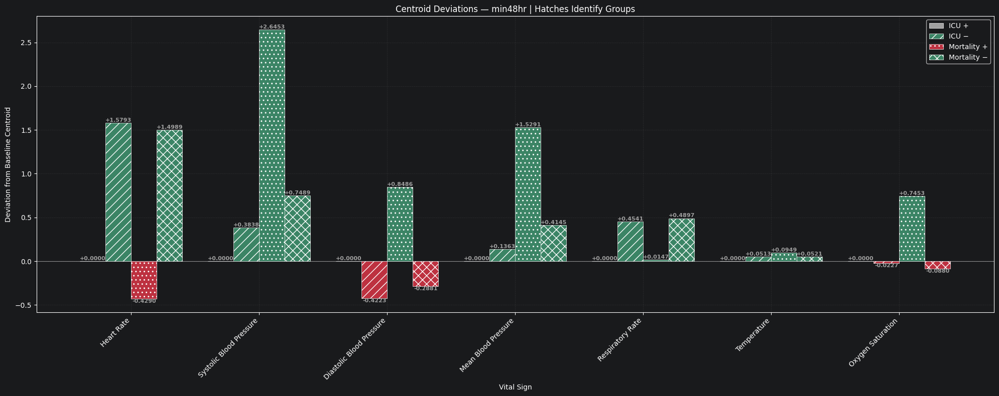

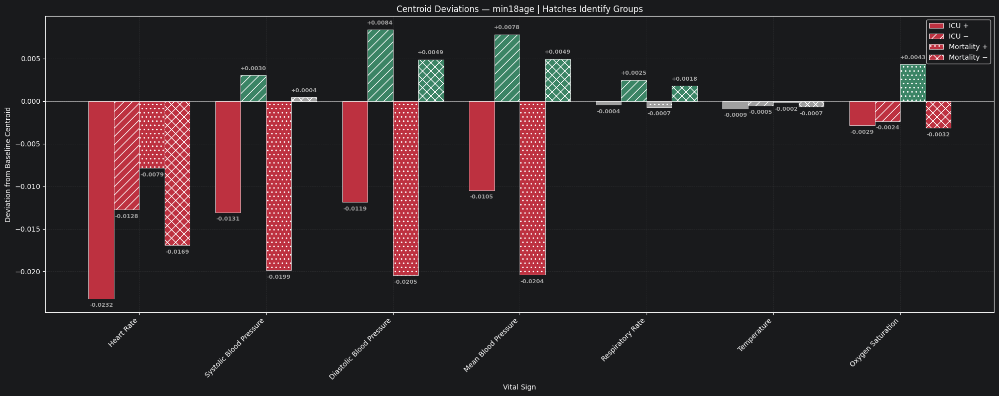

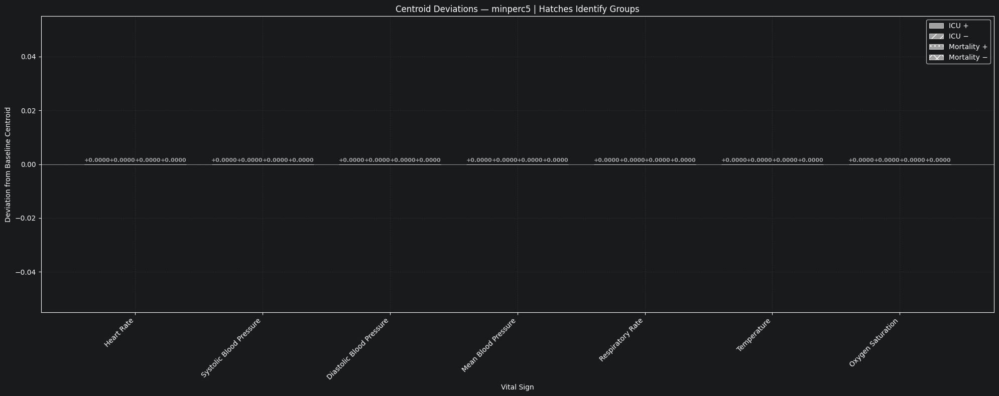


=== Centroid shift bars: median ===


median centroid bars:   0%|          | 0/12 [00:00<?, ?it/s]

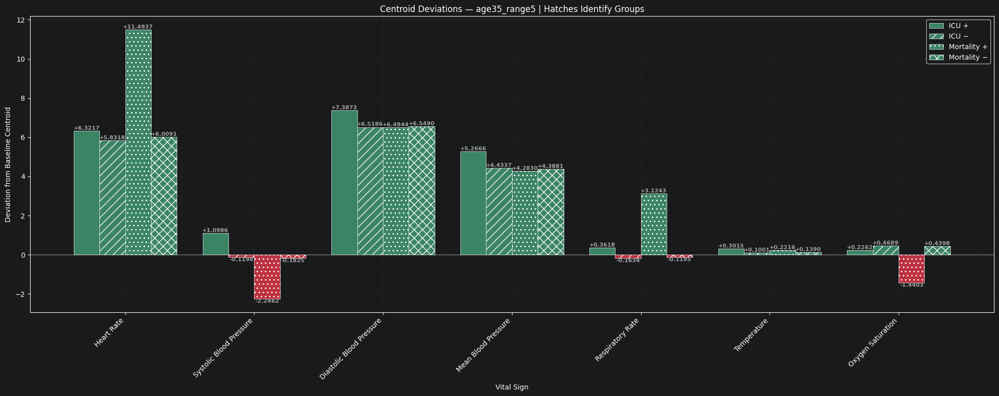

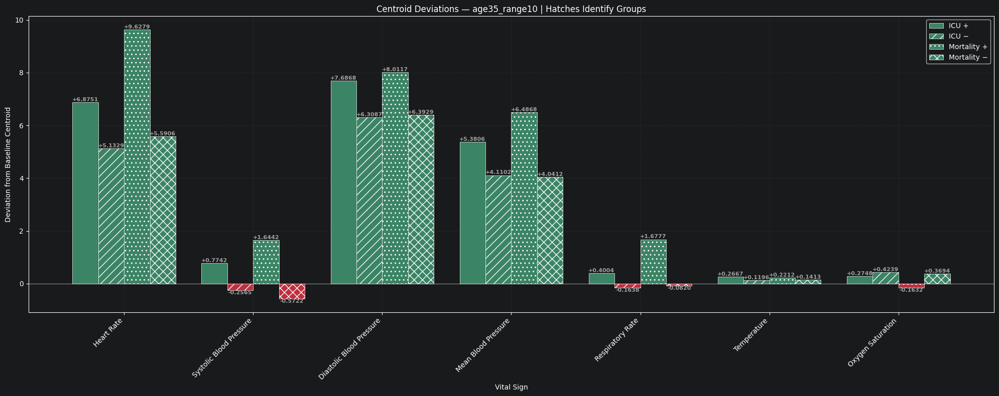

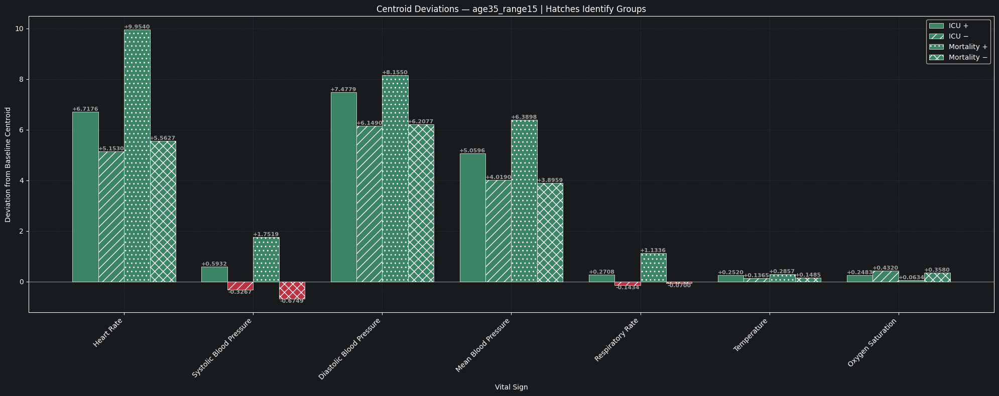

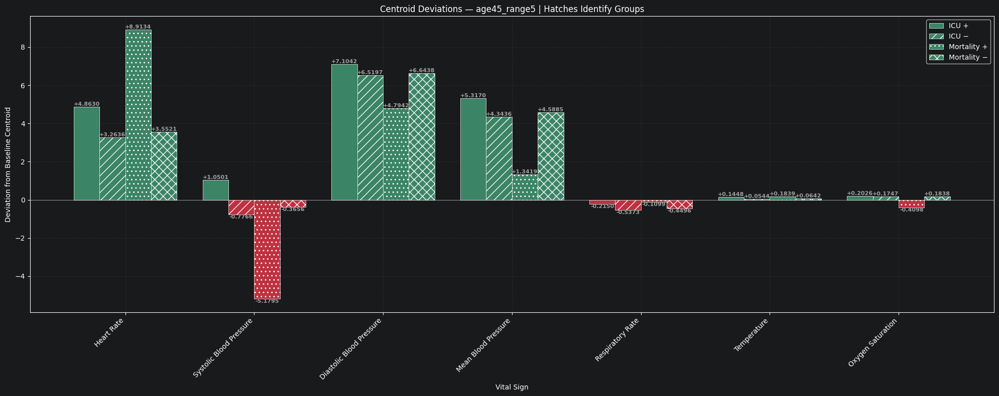

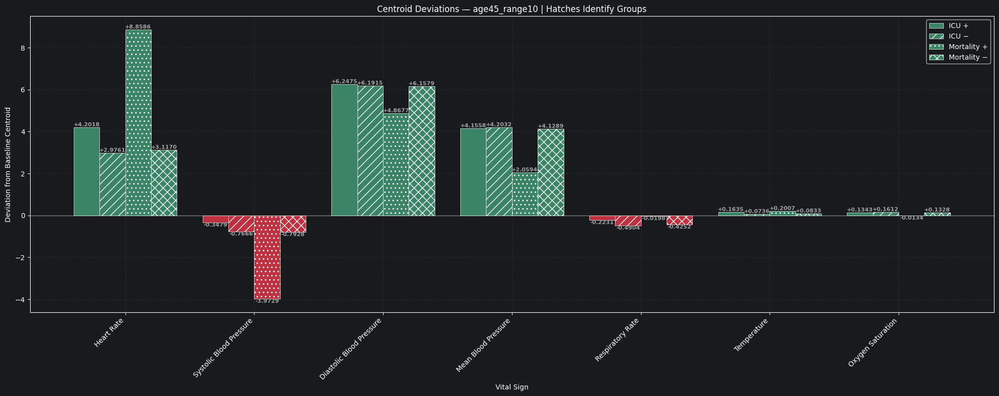

...

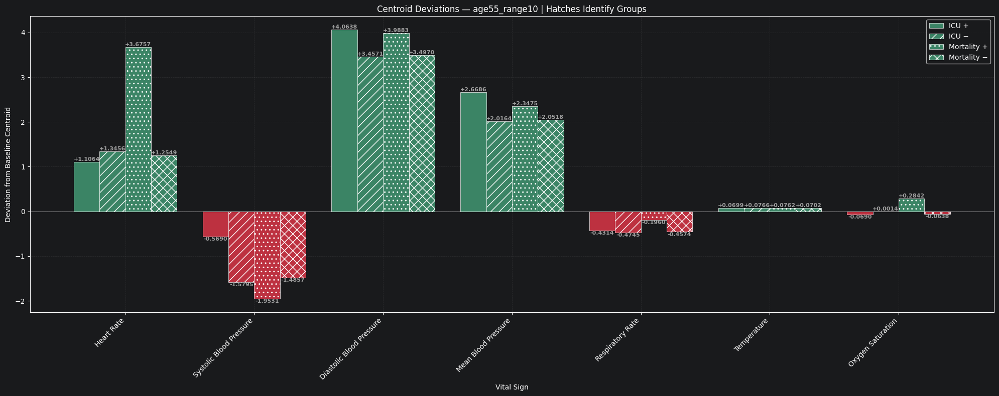

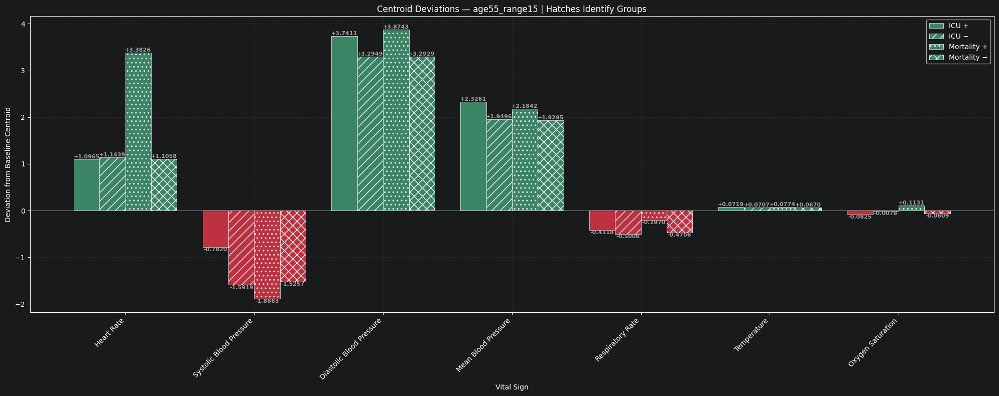

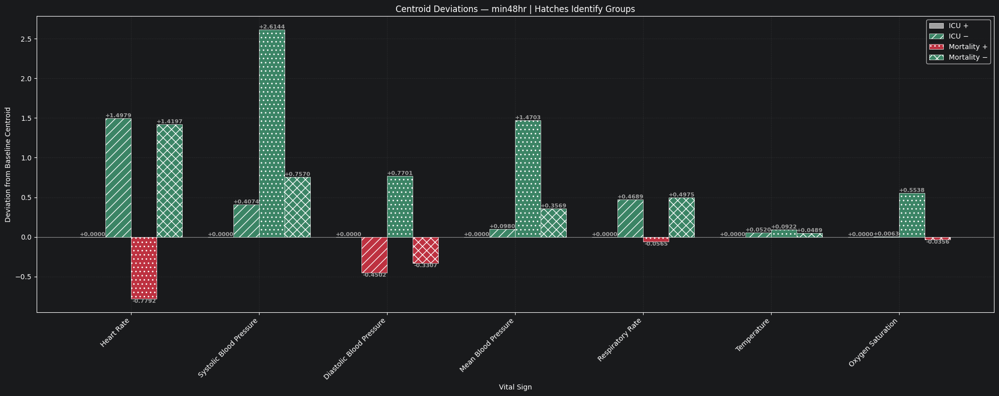

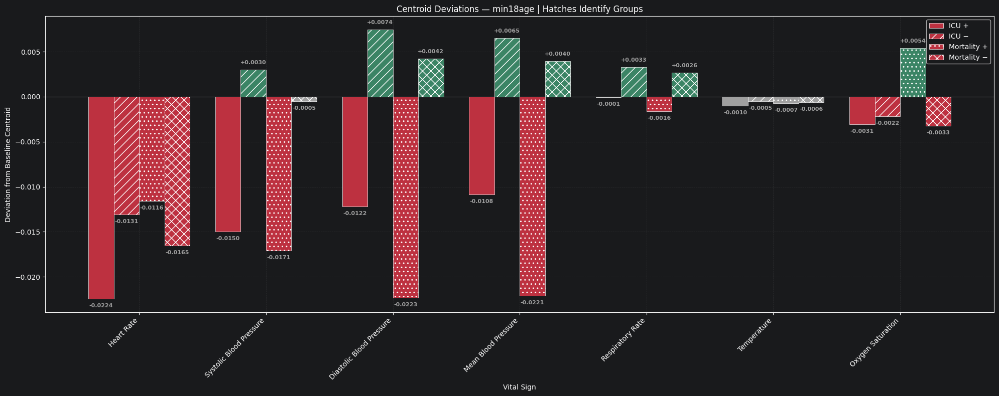

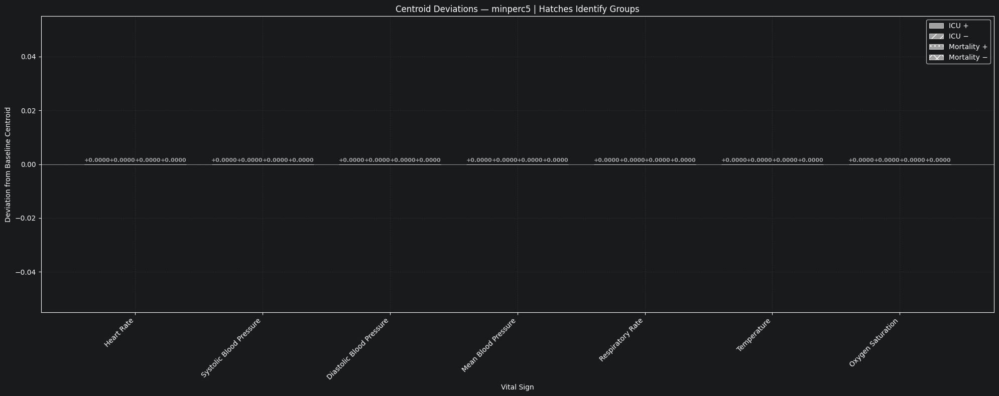


=== Centroid shift bars: standard deviation ===


standard deviation centroid bars:   0%|          | 0/12 [00:00<?, ?it/s]

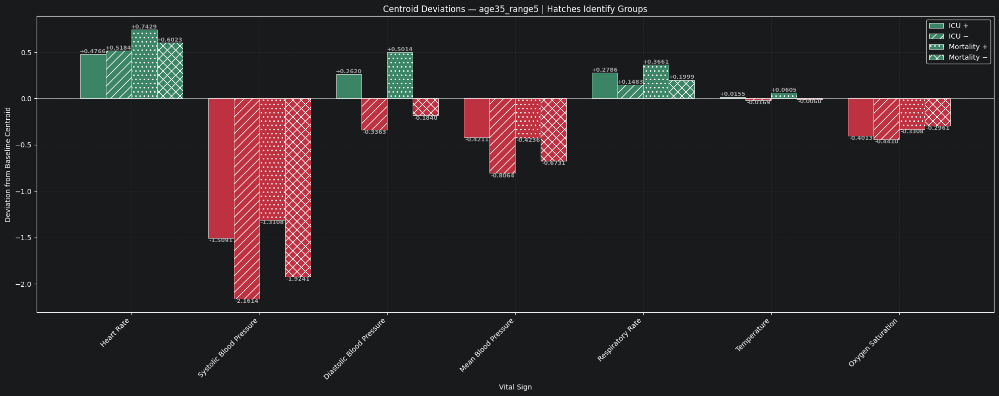

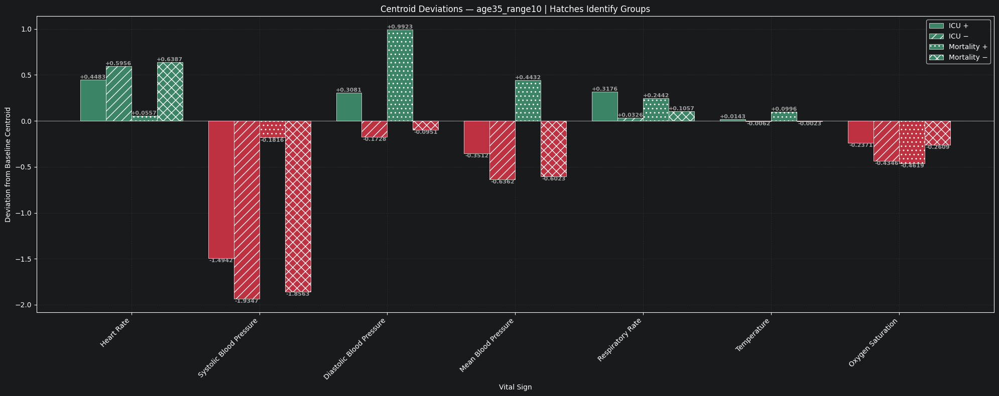

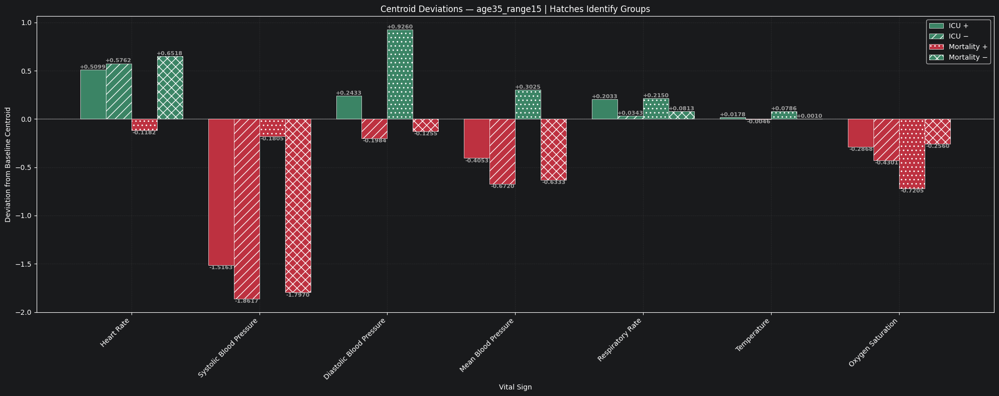

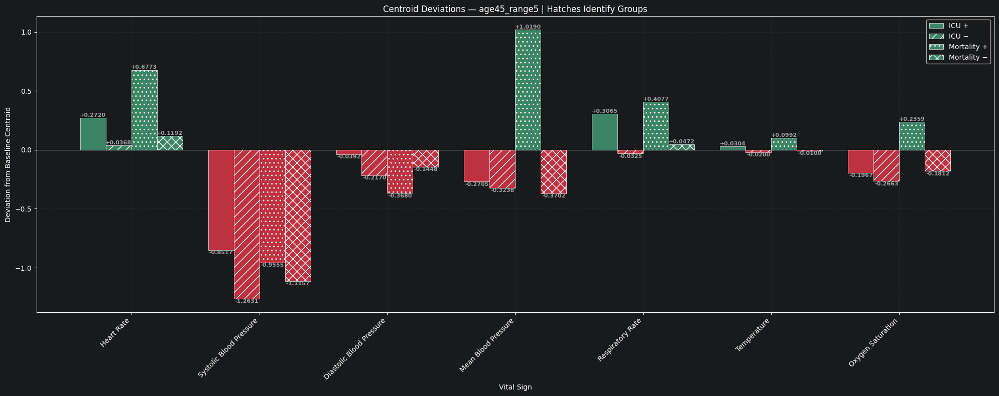

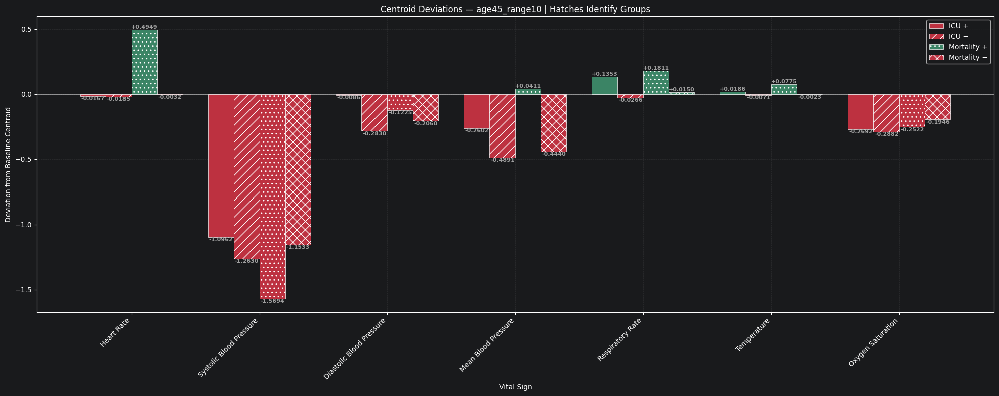

...

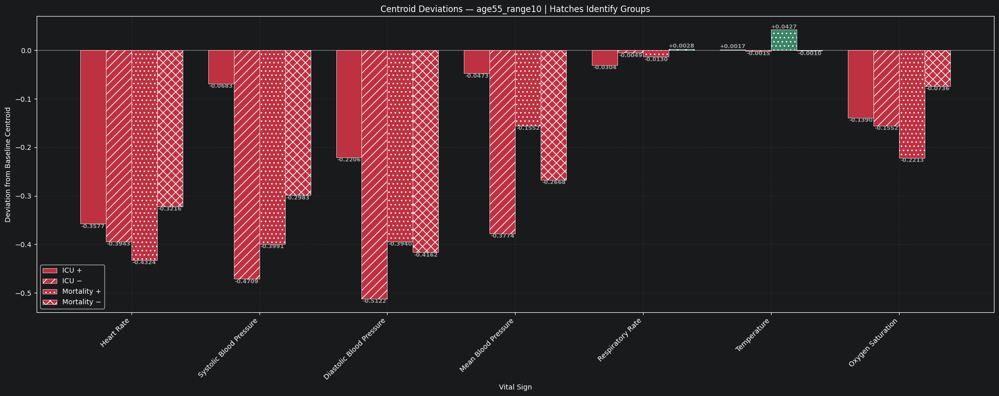

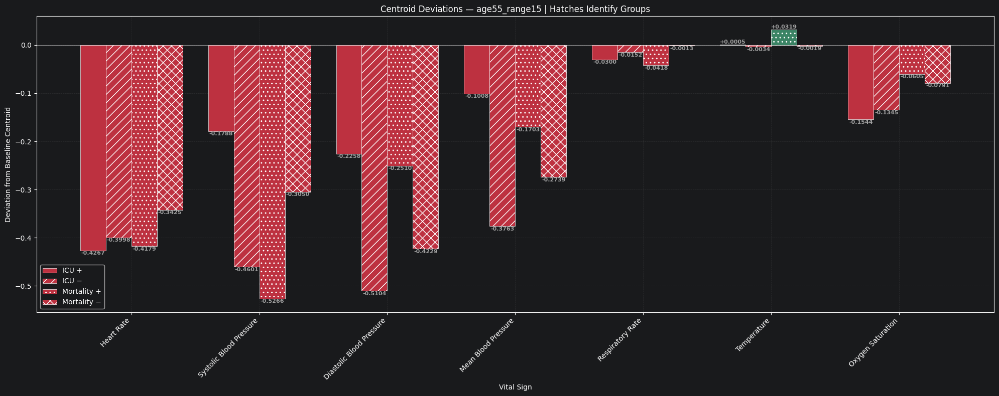

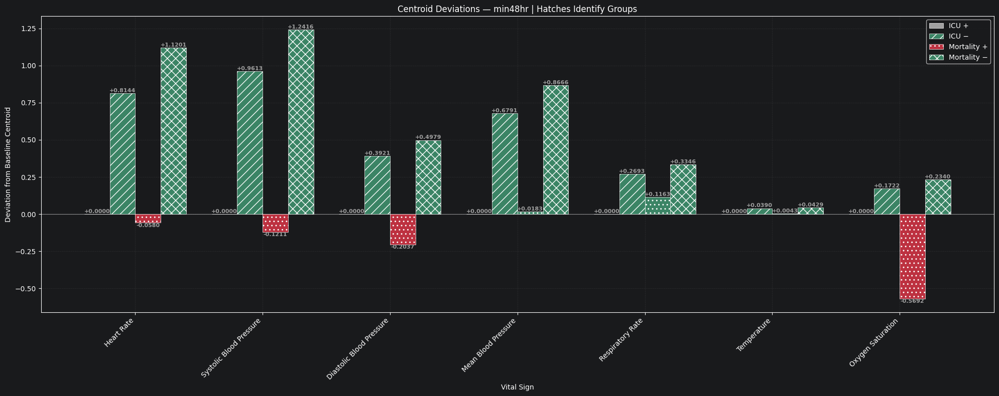

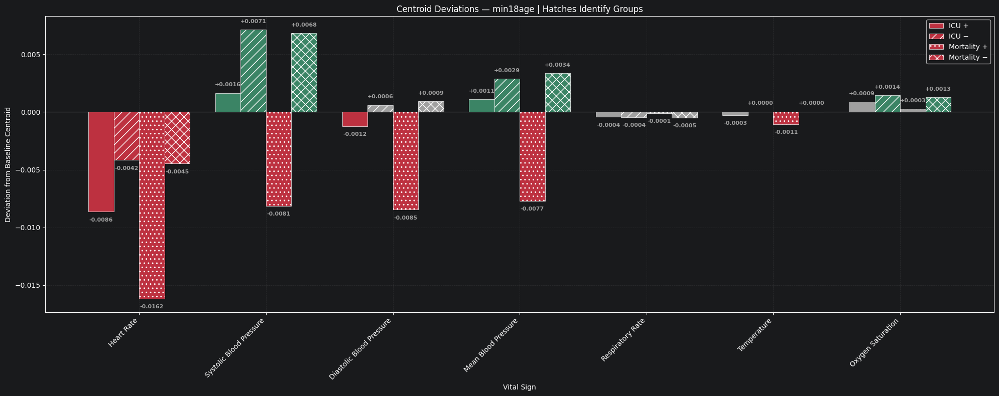

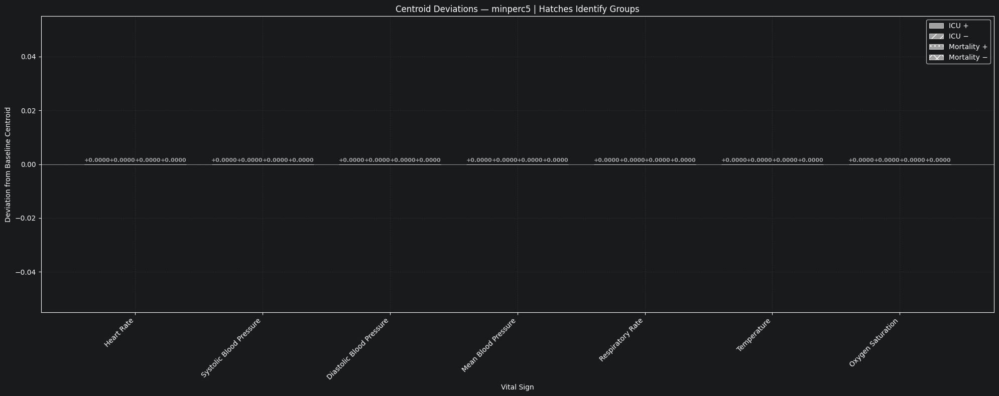


=== Centroid shift bars: mean deviation ===


mean deviation centroid bars:   0%|          | 0/12 [00:00<?, ?it/s]

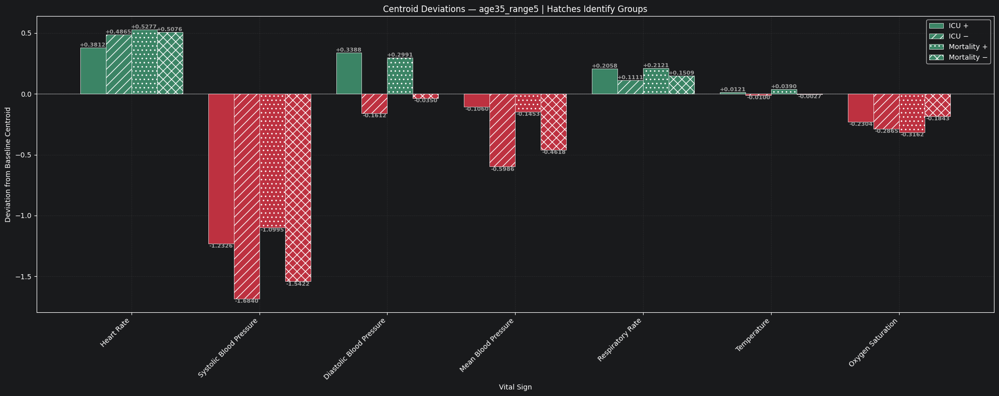

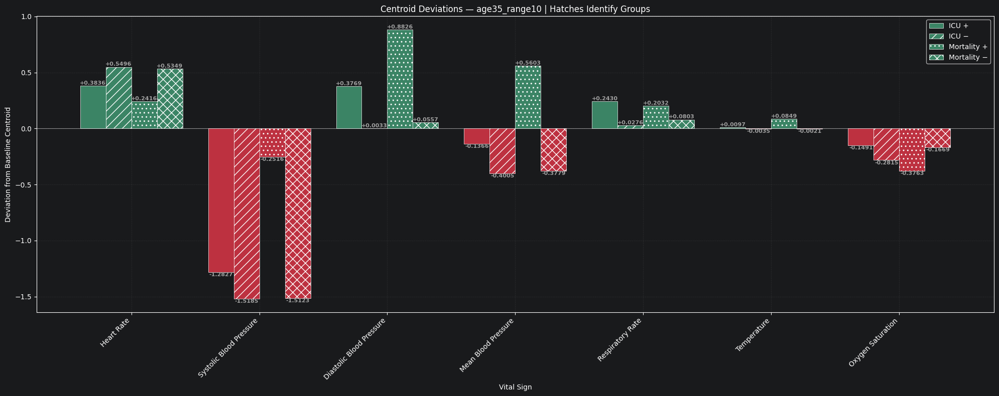

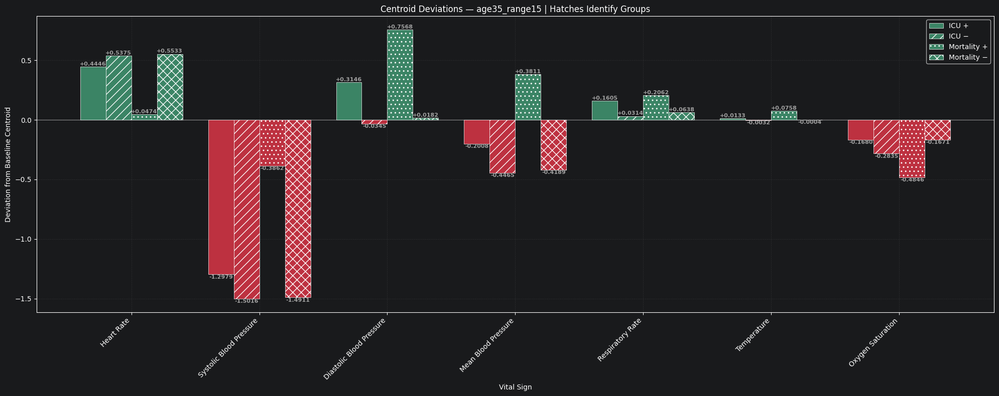

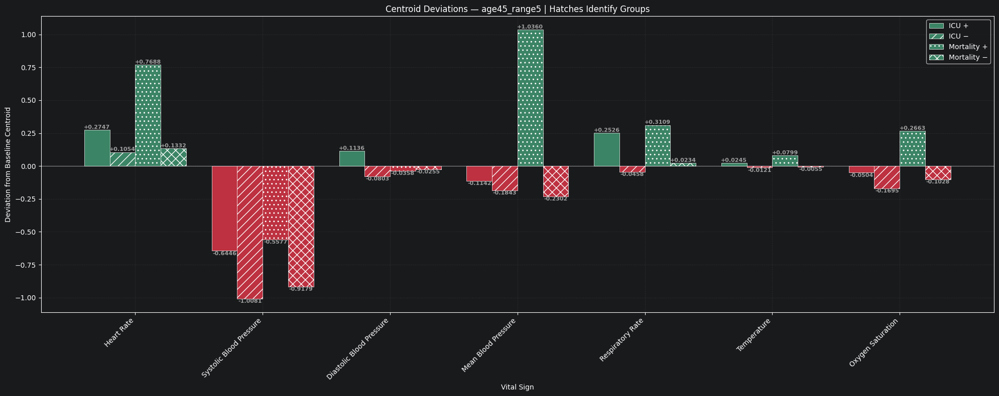

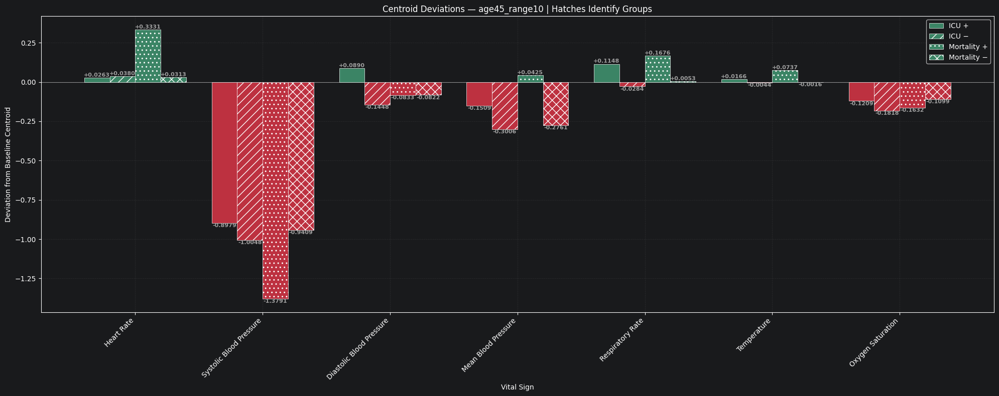

...

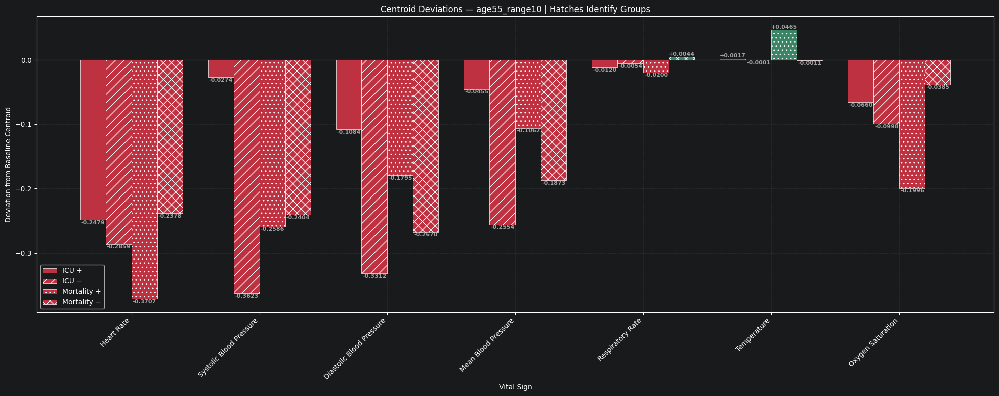

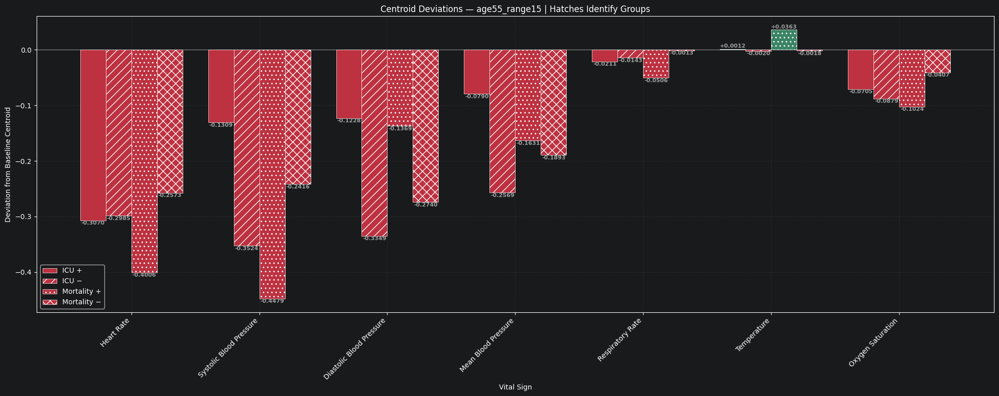

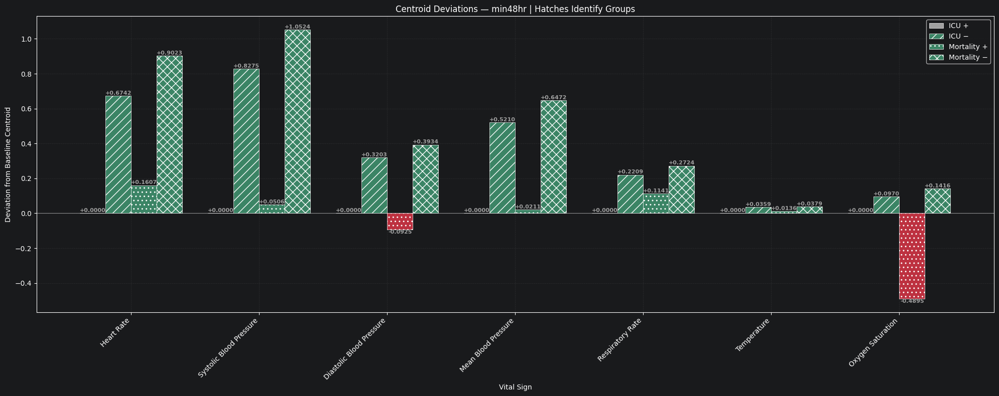

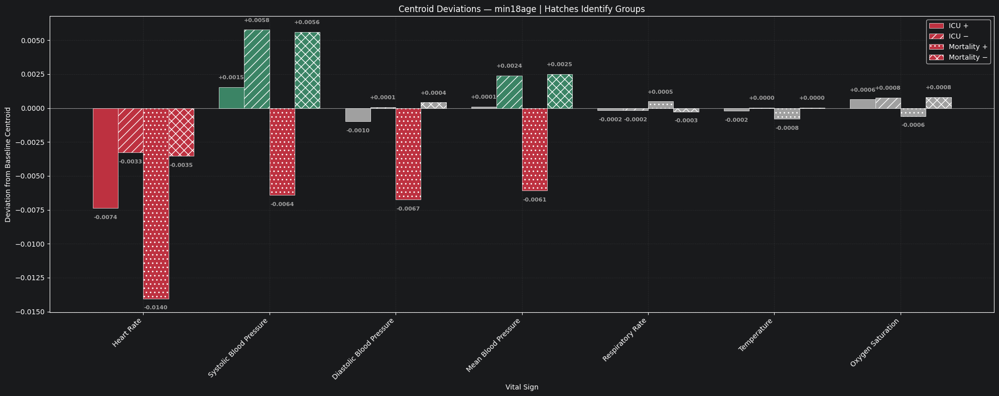

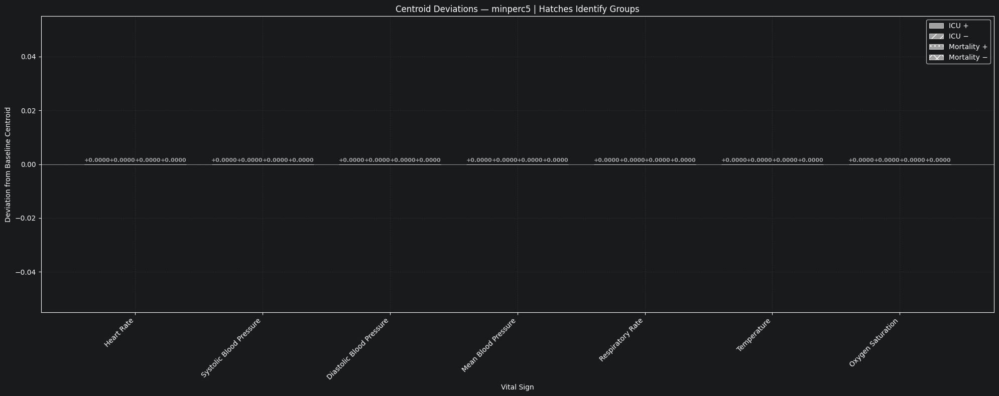


=== Centroid shift bars: maximum deviation ===


maximum deviation centroid bars:   0%|          | 0/12 [00:00<?, ?it/s]

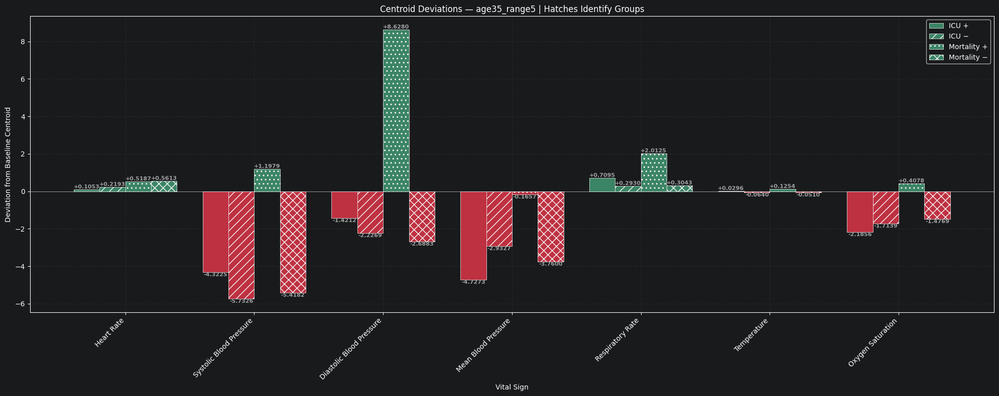

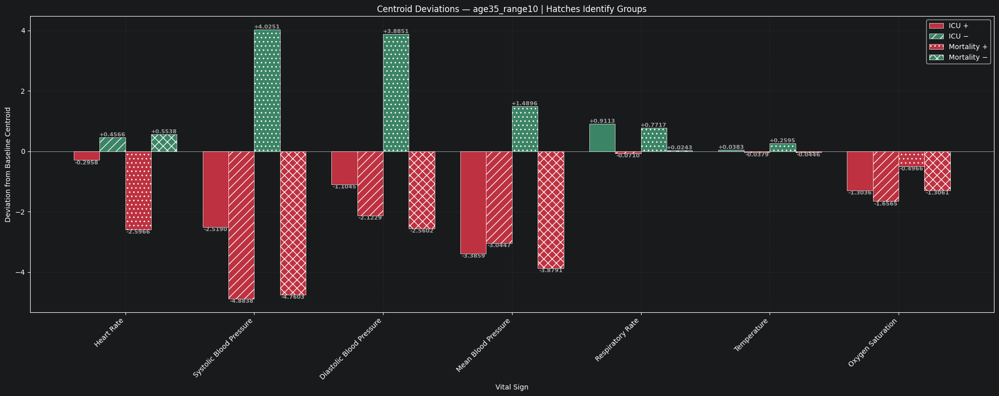

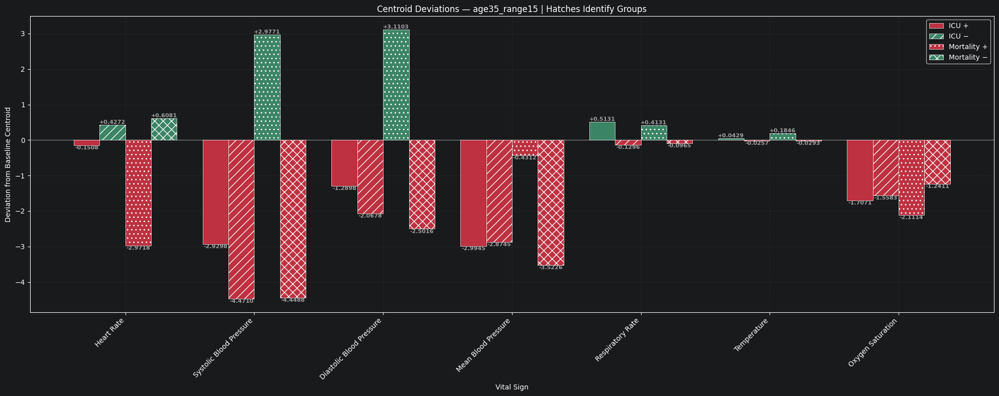

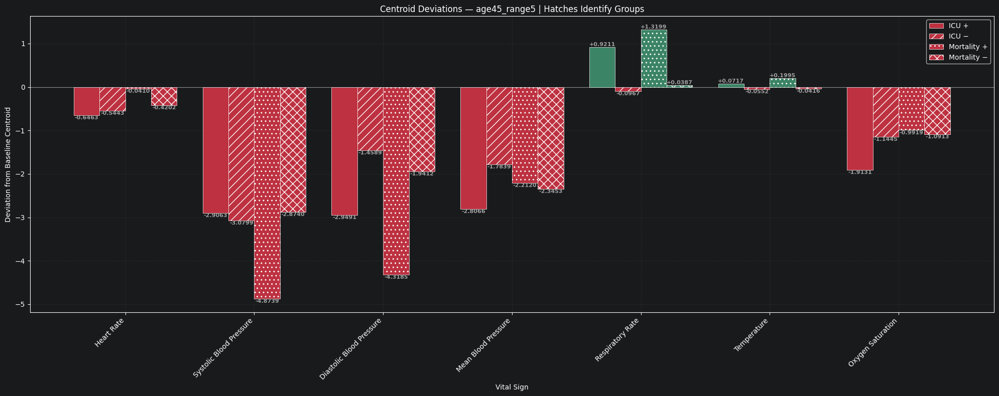

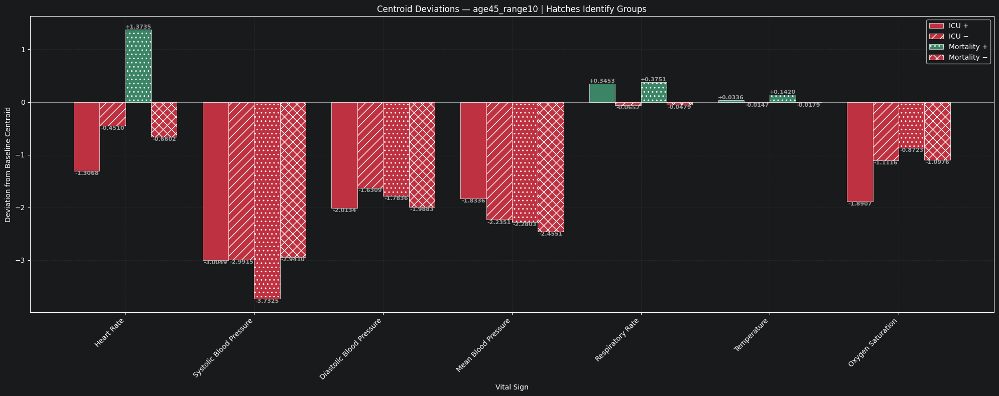

...

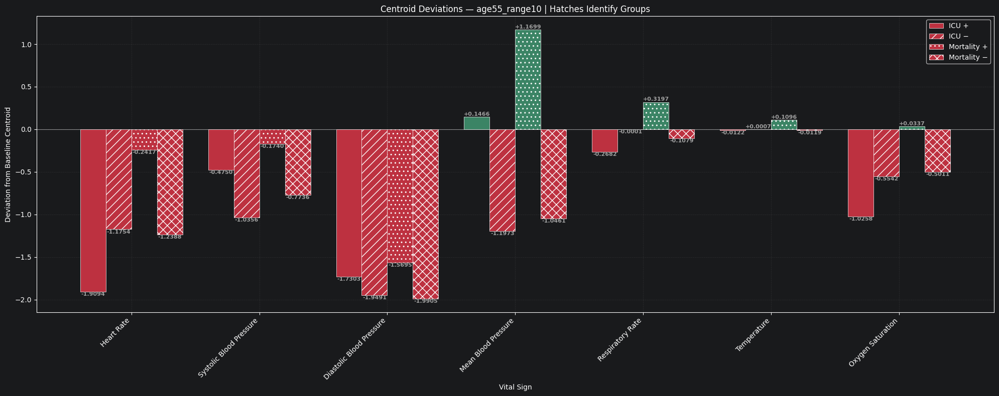

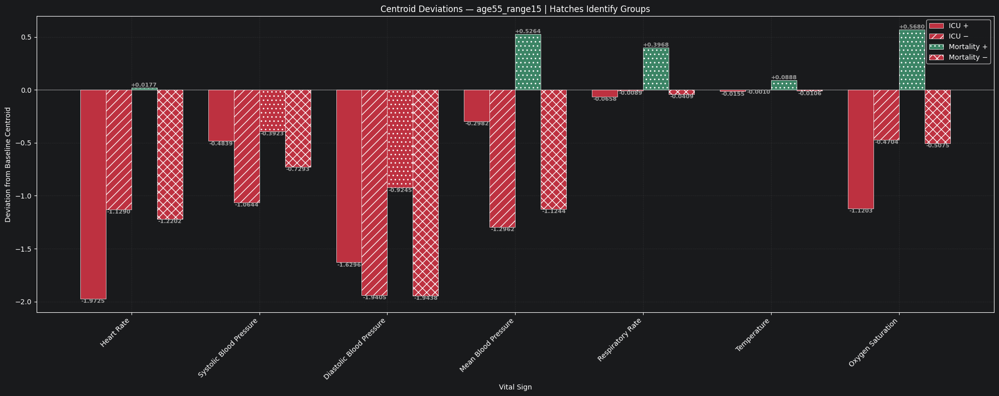

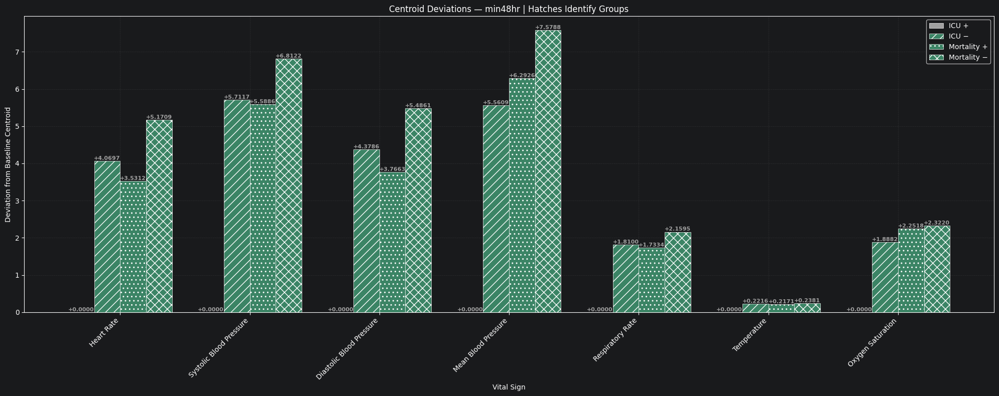

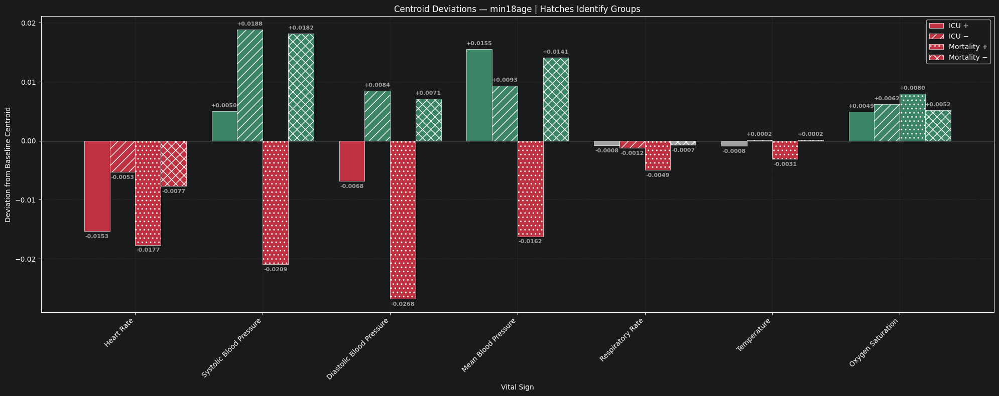

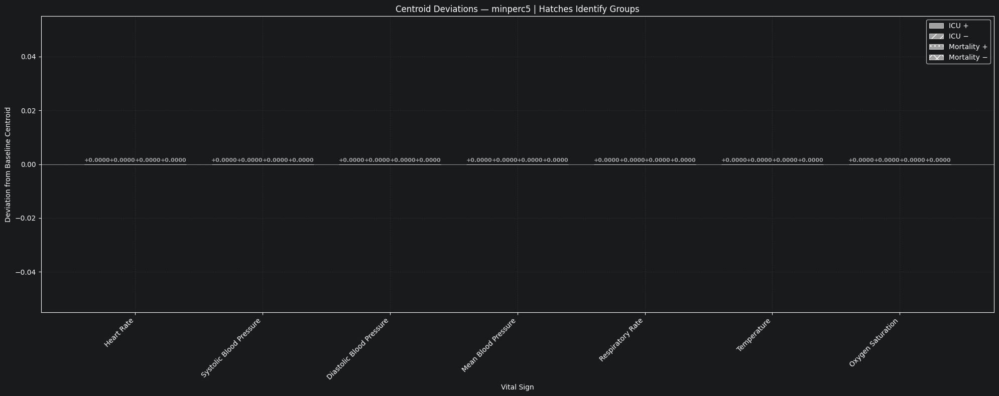

In [13]:
for _method in AGG_METHODS:
    print(f'\n=== Centroid shift bars: {_method} ===')
    base_pat   = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
    X_base_sm  = subset_X_by_patients(BASELINE['X'], base_pat)
    X_base_agg = build_record_aggregated_features(X_base_sm, _method).loc[base_pat.index]

    for v in tqdm(VARIANT_OBJS, desc=f'{_method} centroid bars'):
        v_pat  = maybe_sample_record_ids(v['patients'], MAX_RECORDS_PER_SCENARIO)
        X_vf   = v.get('X') or pd.read_hdf(str(v['datafile']), 'vitals_labs')
        X_vsm  = subset_X_by_patients(X_vf, v_pat)
        X_vagg = build_record_aggregated_features(X_vsm, _method).loc[v_pat.index]

        shift_tuples = []
        for _label in ('icu_los', 'mortality'):
            for polarity in ('pos', 'neg'):
                cb = extract_vital_centroid(X_base_agg, base_pat, _label, VITAL_NAMES, polarity)
                cv = extract_vital_centroid(X_vagg,     v_pat,    _label, VITAL_NAMES, polarity)
                shift_tuples.append((cb, cv))

        titles = ['ICU +', 'ICU −', 'Mortality +', 'Mortality −']
        visualize_centroid_shift_v2(shift_tuples, titles, v['name'],
                                    vital_names=VITAL_NAMES)
        try:
            del X_vf, X_vsm, X_vagg
        except Exception:
            pass


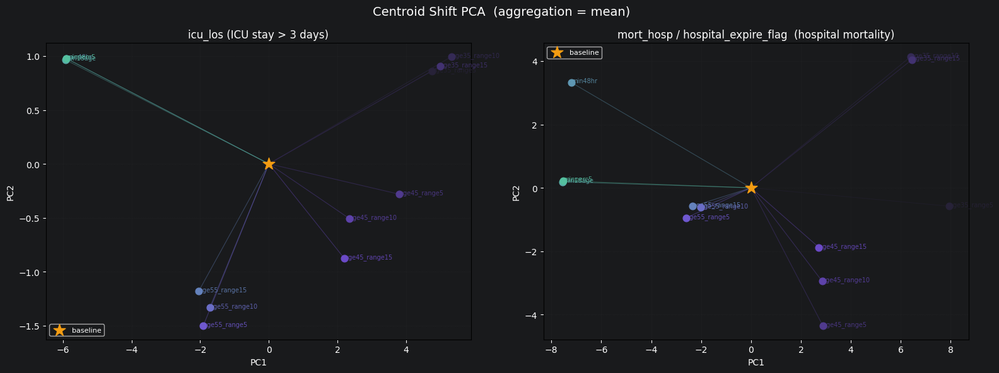

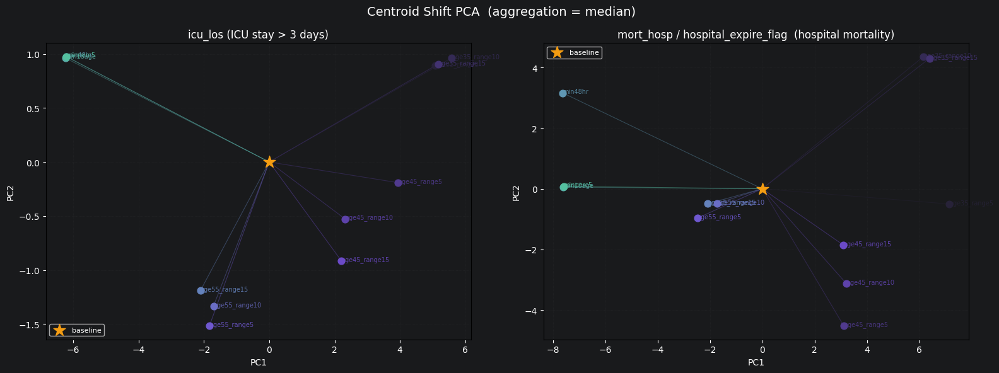

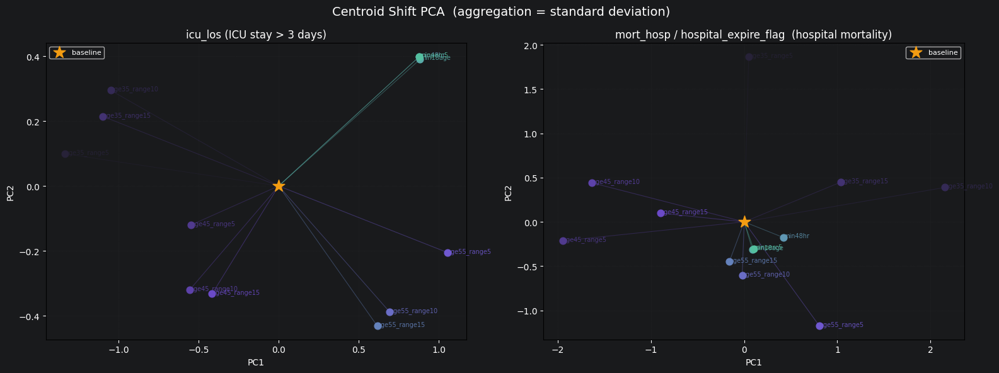

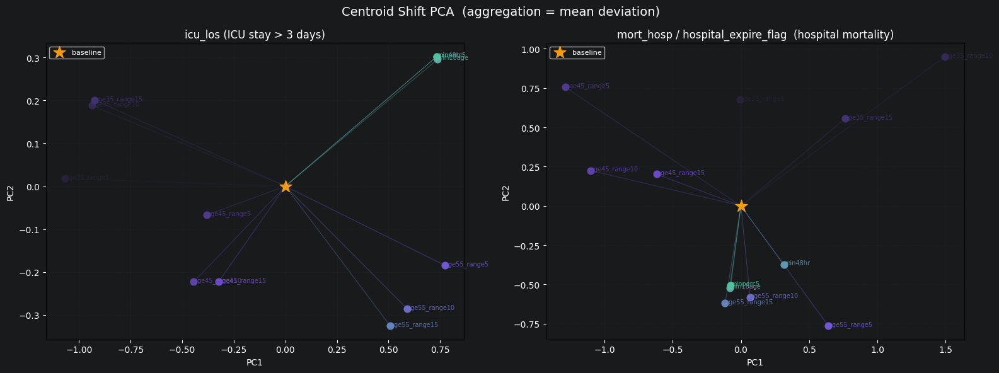

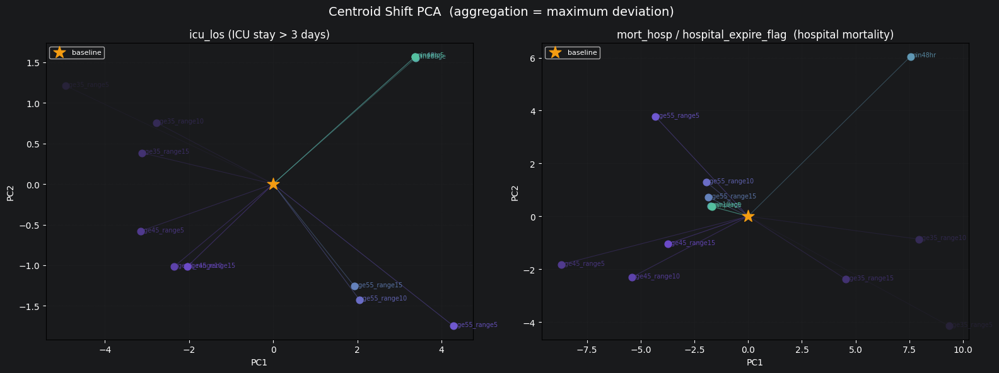

In [14]:
for _method in AGG_METHODS:
    base_pat   = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
    X_base_sm  = subset_X_by_patients(BASELINE['X'], base_pat)
    X_base_agg = build_record_aggregated_features(X_base_sm, _method).loc[base_pat.index]

    variant_aggs = []
    for v in VARIANT_OBJS:
        v_pat  = maybe_sample_record_ids(v['patients'], MAX_RECORDS_PER_SCENARIO)
        X_vf   = v.get('X') or pd.read_hdf(str(v['datafile']), 'vitals_labs')
        X_vsm  = subset_X_by_patients(X_vf, v_pat)
        X_vagg = build_record_aggregated_features(X_vsm, _method).loc[v_pat.index]
        variant_aggs.append({'name': v['name'], 'pat': v_pat, 'X': X_vagg, 'cols': X_vagg.columns})
        try:
            del X_vf, X_vsm
        except Exception:
            pass

    global_shared = X_base_agg.columns
    for va in variant_aggs:
        global_shared = global_shared.intersection(va['cols'])
    Xb_g = X_base_agg[global_shared]

    cmap_v = generate_hex_gradient(_AURORA, len(VARIANT_OBJS) + 2)[1:-1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=_BG)
    for ax, _label in zip(axes, LABELS):
        cb = compute_centroid(Xb_g, base_pat, _label)
        if cb is None:
            ax.set_title(f'{LABEL_DISPLAY[_label]} (no baseline centroid)', color='white')
            continue

        shift_vecs, names_pca = [], []
        for i, va in enumerate(variant_aggs):
            cv = compute_centroid(va['X'][global_shared], va['pat'], _label)
            if cv is None:
                continue
            n_drop = len(X_base_agg.columns) - len(va['cols'])
            lbl    = va['name'] + (f' (-{n_drop})' if n_drop else '')
            shift_vecs.append(cv - cb);  names_pca.append(lbl)

        if len(shift_vecs) < 2:
            ax.set_title(f'{LABEL_DISPLAY[_label]} (insufficient variants)', color='white')
            continue

        Z = PCA(n_components=2, random_state=0).fit_transform(np.vstack(shift_vecs))
        ax.set_facecolor(_BG)
        ax.scatter([0], [0], marker='*', s=200, c='#f39c12', zorder=5, label='baseline')
        for i, (nm, zp) in enumerate(zip(names_pca, Z)):
            c = cmap_v[i % len(cmap_v)]
            ax.scatter([zp[0]], [zp[1]], s=60, color=c, zorder=4)
            ax.annotate(nm, (zp[0], zp[1]), fontsize=7, alpha=0.85, color=c)
            ax.plot([0, zp[0]], [0, zp[1]], linewidth=0.8, color=c, alpha=0.4)
        ax.set_title(f'{LABEL_DISPLAY[_label]}', color='white')
        ax.set_xlabel('PC1', color='white');  ax.set_ylabel('PC2', color='white')
        ax.grid(color='#3a3b3d', linestyle=':', linewidth=0.5, alpha=0.4)
        ax.legend(facecolor=_BG, labelcolor='white', fontsize=8)

    plt.suptitle(f'Centroid Shift PCA  (aggregation = {_method})', color='white', fontsize=14)
    plt.tight_layout();  plt.show()


# Extra Visualizations

Prevalence by scenario and record-length distributions.

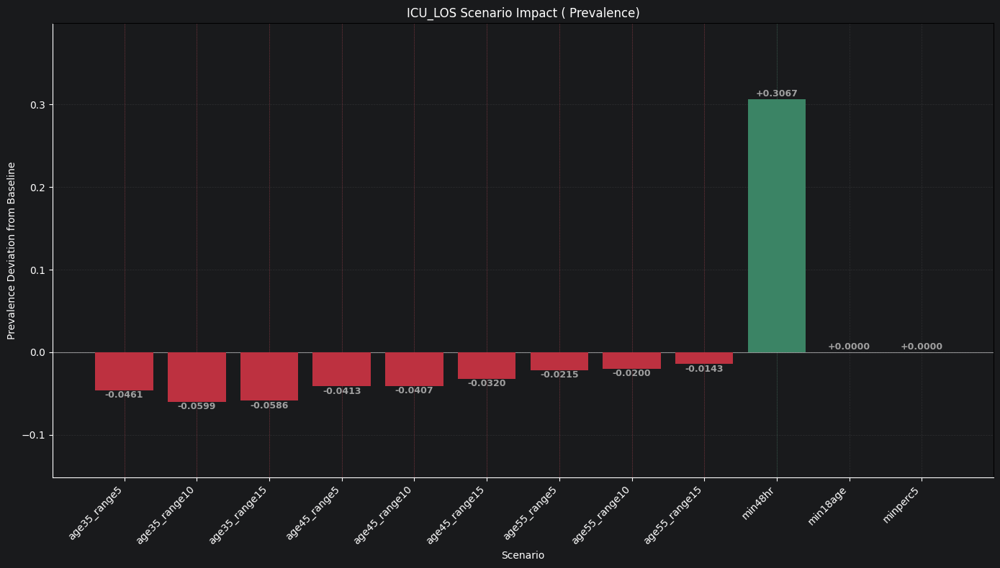

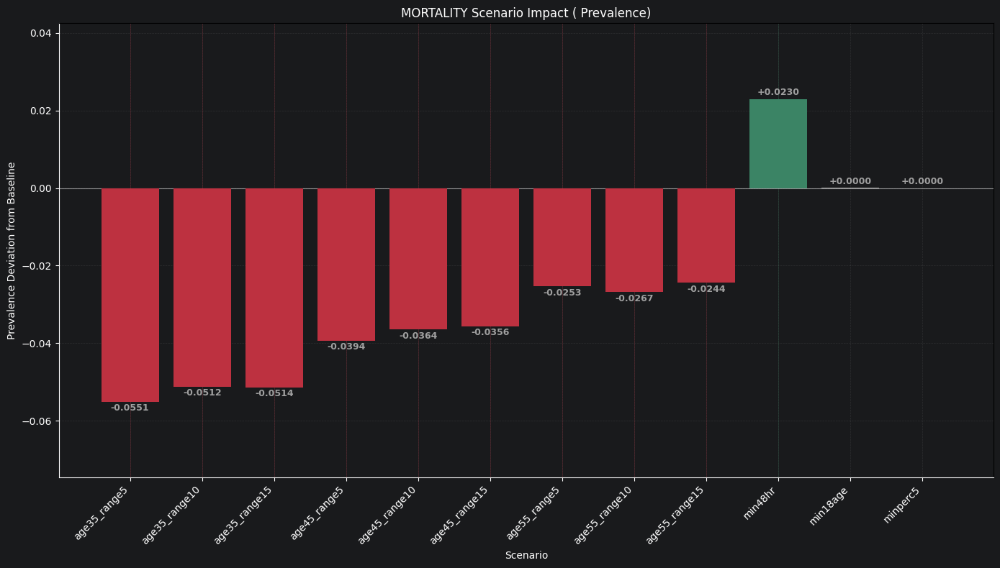

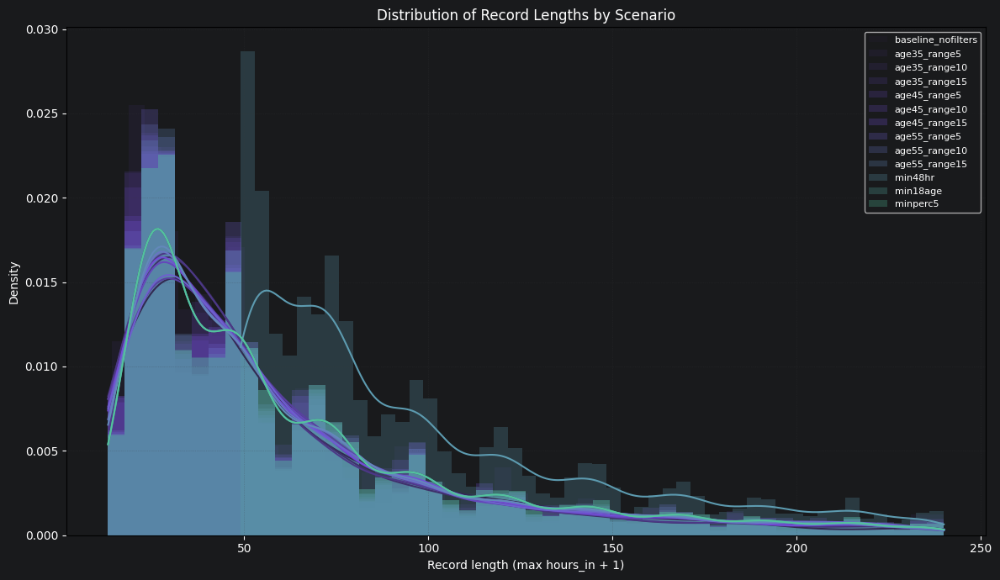

In [15]:
# ── Prevalence ─────────────────────────────────────────────────────────────────
prev_rows = []
for v in [BASELINE] + VARIANT_OBJS:
    for _label in LABELS:
        y = _select_pos_label(v['patients'], _label)
        prev_rows.append({'scenario': v['name'], 'target': _label, 'prev': float(y.mean())})

df_prev = pd.DataFrame(prev_rows)

for _label in LABELS:
    sub   = df_prev[df_prev['target'] == _label]
    names = sub['scenario'].tolist()
    prevs = sub['prev'].tolist()
    # Build as "scores" list with baseline first for visualize_scenario_impact reuse
    visualize_scenario_impact(
        prevs,
        names[1:],
        label=_label,
        metric='Prevalence',
        aggregation_method='',
    )

# ── Record-length KDE ──────────────────────────────────────────────────────────
palette = generate_hex_gradient(_AURORA, len(VARIANT_OBJS) + 3)[1:-1]

fig, ax = plt.subplots(figsize=(12, 7), facecolor=_BG)
ax.set_facecolor(_BG)

for i, v in enumerate([BASELINE] + VARIANT_OBJS):
    sc_dir = Path(v['datafile']).parent
    fp_path = sc_dir / 'fenceposts.npy'
    if not fp_path.exists():
        continue
    fp     = np.load(str(fp_path))
    lens   = fp + 1
    c      = palette[i % len(palette)]
    ax.hist(lens, bins=50, density=True, alpha=0.25, color=c, label=v['name'])
    # KDE via simple Gaussian
    from scipy.stats import gaussian_kde
    try:
        kde = gaussian_kde(lens)
        xs  = np.linspace(lens.min(), lens.max(), 300)
        ax.plot(xs, kde(xs), color=c, linewidth=1.5)
    except Exception:
        pass

ax.set_xlabel('Record length (max hours_in + 1)', color='white')
ax.set_ylabel('Density', color='white')
ax.set_title('Distribution of Record Lengths by Scenario', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor=_BG, labelcolor='white', fontsize=8)
ax.grid(color='#3a3b3d', linestyle=':', linewidth=0.5, alpha=0.4)
plt.tight_layout();  plt.show()
